## Experiment 03: CLIP Item-level Feature Fusion

Experiment 02의 ResNet18 grid image baseline은 outfit 전체를 하나의 이미지로 합성한 뒤 compatible/incompatible을 분류하였다. 그러나 grid 방식은 각 fashion item 간의 관계를 명시적으로 표현하지 못한다는 한계가 있었다.

Experiment 03에서는 각 outfit을 구성하는 item 이미지를 개별적으로 처리한다. 각 item image를 CLIP image encoder에 입력하여 embedding을 추출하고, outfit 단위로 item embedding을 결합한 뒤 MLP classifier를 학습한다.

첫 단계에서는 Experiment 02에서 생성한 valid sample 및 split metadata를 재사용할 수 있는지 확인한다.

Google Drive 연결 및 기본 경로 설정

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Experiment 02 데이터 경로 확인

In [2]:
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/aesthetic-ai")
EXP02_DIR = PROJECT_ROOT / "data" / "experiment_02_polyvore_grids"

print("PROJECT_ROOT exists:", PROJECT_ROOT.exists())
print("EXP02_DIR exists:", EXP02_DIR.exists())
print("EXP02_DIR:", EXP02_DIR)

if EXP02_DIR.exists():
    print("\n[Files in EXP02_DIR]")
    for p in sorted(EXP02_DIR.iterdir()):
        print("-", p.name)
else:
    print("Experiment 02 directory not found.")

PROJECT_ROOT exists: True
EXP02_DIR exists: True
EXP02_DIR: /content/drive/MyDrive/aesthetic-ai/data/experiment_02_polyvore_grids

[Files in EXP02_DIR]
- images
- labels.csv
- labels_split.csv


Experiment 02 관련 파일 전체 탐색

In [3]:
from pathlib import Path

search_root = PROJECT_ROOT / "data"

target_keywords = [
    "valid",
    "sample",
    "split",
    "label",
    "train",
    "val",
    "polyvore"
]

matched_files = []

for p in search_root.rglob("*"):
    if p.is_file():
        name = p.name.lower()
        if any(keyword in name for keyword in target_keywords):
            matched_files.append(p)

print(f"Matched files: {len(matched_files)}")

for p in sorted(matched_files):
    print(p)

Matched files: 22
/content/drive/MyDrive/aesthetic-ai/data/experiment_02_polyvore_grids/labels.csv
/content/drive/MyDrive/aesthetic-ai/data/experiment_02_polyvore_grids/labels_split.csv
/content/drive/MyDrive/aesthetic-ai/data/labels/labels.csv
/content/drive/MyDrive/aesthetic-ai/data/labels/sample_labels.csv
/content/drive/MyDrive/aesthetic-ai/data/labels/train_labels.csv
/content/drive/MyDrive/aesthetic-ai/data/labels/val_labels.csv
/content/drive/MyDrive/aesthetic-ai/data/polyvore_xthan/.git/hooks/applypatch-msg.sample
/content/drive/MyDrive/aesthetic-ai/data/polyvore_xthan/.git/hooks/commit-msg.sample
/content/drive/MyDrive/aesthetic-ai/data/polyvore_xthan/.git/hooks/fsmonitor-watchman.sample
/content/drive/MyDrive/aesthetic-ai/data/polyvore_xthan/.git/hooks/post-update.sample
/content/drive/MyDrive/aesthetic-ai/data/polyvore_xthan/.git/hooks/pre-applypatch.sample
/content/drive/MyDrive/aesthetic-ai/data/polyvore_xthan/.git/hooks/pre-commit.sample
/content/drive/MyDrive/aesthetic-a

CSV / JSON 후보 파일 내용 미리보기

In [4]:
import json
import pandas as pd

candidate_files = []

for p in matched_files:
    if p.suffix.lower() in [".csv", ".json", ".jsonl"]:
        candidate_files.append(p)

print(f"Candidate metadata files: {len(candidate_files)}")

for idx, p in enumerate(candidate_files):
    print(f"\n[{idx}] {p}")
    try:
        if p.suffix.lower() == ".csv":
            df = pd.read_csv(p)
            print("shape:", df.shape)
            print("columns:", list(df.columns))
            display(df.head(3))

        elif p.suffix.lower() == ".json":
            with open(p, "r", encoding="utf-8") as f:
                data = json.load(f)

            print("type:", type(data))
            if isinstance(data, list):
                print("length:", len(data))
                print("first item:")
                print(json.dumps(data[0], ensure_ascii=False, indent=2)[:2000])
            elif isinstance(data, dict):
                print("keys:", list(data.keys())[:20])
                first_key = next(iter(data.keys()))
                print("first value:")
                print(json.dumps(data[first_key], ensure_ascii=False, indent=2)[:2000])

        elif p.suffix.lower() == ".jsonl":
            with open(p, "r", encoding="utf-8") as f:
                lines = [next(f) for _ in range(3)]
            for line in lines:
                print(line[:1000])

    except Exception as e:
        print("Could not read file:", e)

Candidate metadata files: 8

[0] /content/drive/MyDrive/aesthetic-ai/data/labels/labels.csv
shape: (255508, 3)
columns: ['image_name', 'score', 'label']


,image_name,score,label
0,953417.jpg,6.112903,1
1,953777.jpg,6.593750,1
2,953756.jpg,5.796875,1



[1] /content/drive/MyDrive/aesthetic-ai/data/labels/sample_labels.csv
shape: (1000, 3)
columns: ['image_name', 'score', 'label']


,image_name,score,label
0,426266.jpg,6.671096,1
1,941927.jpg,6.713043,1
2,684528.jpg,7.343590,1



[2] /content/drive/MyDrive/aesthetic-ai/data/labels/train_labels.csv
shape: (800, 3)
columns: ['image_name', 'score', 'label']


...

,image_name,score,label
0,731759.jpg,6.764706,1
1,210855.jpg,3.958333,0
2,343122.jpg,3.886076,0



[4] /content/drive/MyDrive/aesthetic-ai/data/polyvore_xthan/train_no_dup.json
type: <class 'list'>
length: 17316
first item:
{
  "name": "Casual",
  "views": 8743,
  "items": [
    {
      "index": 1,
      "name": "mock neck embroidery suede sweatshirt",
      "price": 24.0,
      "likes": 10,
      "image": "http://img2.polyvoreimg.com/cgi/img-thing?.out=jpg&size=m&tid=194508109",
      "categoryid": 4495
    },
    {
      "index": 2,
      "name": "luxe double zip hooded jacket",
      "price": 150.0,
      "likes": 2250,
      "image": "http://img2.polyvoreimg.com/cgi/img-thing?.out=jpg&size=m&tid=188778349",
      "categoryid": 25
    },
    {
      "index": 3,
      "name": "citizens humanity high rise rocket hem jean",
      "price": 248.0,
      "likes": 2437,
      "image": "http://img1.polyvoreimg.com/cgi/img-thing?.out=jpg&size=m&tid=188977857",
      "categoryid": 27
    },
    {
      "index": 4,
      "name": "suede tie short boots",
      "price": 37.0,
      "likes": 

,image_path,label,sample_id,num_items
0,/content/drive/MyDrive/aesthetic-ai/data/exper...,1,0,6
1,/content/drive/MyDrive/aesthetic-ai/data/exper...,1,1,4
2,/content/drive/MyDrive/aesthetic-ai/data/exper...,1,2,6



[7] /content/drive/MyDrive/aesthetic-ai/data/experiment_02_polyvore_grids/labels_split.csv
shape: (2420, 5)
columns: ['image_path', 'label', 'sample_id', 'num_items', 'split']


,image_path,label,sample_id,num_items,split
0,/content/drive/MyDrive/aesthetic-ai/data/exper...,1,252,5,train
1,/content/drive/MyDrive/aesthetic-ai/data/exper...,1,312,7,train
2,/content/drive/MyDrive/aesthetic-ai/data/exper...,0,1398,8,train


### Step 2. Experiment 02 metadata reuse check

Experiment 02에서 생성한 labels_split.csv에는 grid image path, label, sample_id, num_items, split 정보가 남아 있었다. 따라서 train/validation split은 Experiment 03에서도 재사용할 수 있다.

다만 labels_split.csv에는 각 outfit을 구성하는 item 목록이 포함되어 있지 않으므로, CLIP item-level feature fusion을 위해서는 xthan Polyvore 원본 JSON과 fashion_compatibility_prediction.txt를 이용해 item-level metadata를 재구성해야 한다.

labels_split과 xthan 원본 파일 구조 확인

In [5]:
from pathlib import Path
import json
import pandas as pd

PROJECT_ROOT = Path("/content/drive/MyDrive/aesthetic-ai")

EXP02_DIR = PROJECT_ROOT / "data" / "experiment_02_polyvore_grids"
XTHAN_DIR = PROJECT_ROOT / "data" / "polyvore_xthan"

labels_split_path = EXP02_DIR / "labels_split.csv"
train_json_path = XTHAN_DIR / "train_no_dup.json"
valid_json_path = XTHAN_DIR / "valid_no_dup.json"
compat_path = XTHAN_DIR / "fashion_compatibility_prediction.txt"

print("[Path Check]")
print("labels_split:", labels_split_path.exists(), labels_split_path)
print("train_no_dup.json:", train_json_path.exists(), train_json_path)
print("valid_no_dup.json:", valid_json_path.exists(), valid_json_path)
print("fashion_compatibility_prediction.txt:", compat_path.exists(), compat_path)

print("\n[labels_split.csv]")
labels_split = pd.read_csv(labels_split_path)
print("shape:", labels_split.shape)
print("columns:", list(labels_split.columns))
display(labels_split.head())
print("\nsplit counts:")
print(labels_split["split"].value_counts())
print("\nlabel counts by split:")
print(pd.crosstab(labels_split["split"], labels_split["label"]))

print("\n[train_no_dup.json sample]")
with open(train_json_path, "r", encoding="utf-8") as f:
    train_data = json.load(f)

print("type:", type(train_data))
print("length:", len(train_data))

first_train = train_data[0]
print("first item type:", type(first_train))
print(json.dumps(first_train, ensure_ascii=False, indent=2)[:3000])

print("\n[valid_no_dup.json sample]")
with open(valid_json_path, "r", encoding="utf-8") as f:
    valid_data = json.load(f)

print("type:", type(valid_data))
print("length:", len(valid_data))

first_valid = valid_data[0]
print("first item type:", type(first_valid))
print(json.dumps(first_valid, ensure_ascii=False, indent=2)[:3000])

print("\n[fashion_compatibility_prediction.txt sample]")
with open(compat_path, "r", encoding="utf-8") as f:
    lines = [next(f).strip() for _ in range(10)]

for i, line in enumerate(lines):
    print(f"{i}: {line}")

[Path Check]
labels_split: True /content/drive/MyDrive/aesthetic-ai/data/experiment_02_polyvore_grids/labels_split.csv
train_no_dup.json: True /content/drive/MyDrive/aesthetic-ai/data/polyvore_xthan/train_no_dup.json
valid_no_dup.json: True /content/drive/MyDrive/aesthetic-ai/data/polyvore_xthan/valid_no_dup.json
fashion_compatibility_prediction.txt: True /content/drive/MyDrive/aesthetic-ai/data/polyvore_xthan/fashion_compatibility_prediction.txt

[labels_split.csv]
shape: (2420, 5)
columns: ['image_path', 'label', 'sample_id', 'num_items', 'split']


,image_path,label,sample_id,num_items,split
0,/content/drive/MyDrive/aesthetic-ai/data/exper...,1,252,5,train
1,/content/drive/MyDrive/aesthetic-ai/data/exper...,1,312,7,train
2,/content/drive/MyDrive/aesthetic-ai/data/exper...,0,1398,8,train
3,/content/drive/MyDrive/aesthetic-ai/data/exper...,0,1698,4,train
4,/content/drive/MyDrive/aesthetic-ai/data/exper...,0,1154,5,train



split counts:
split
train    1936
val       484
Name: count, dtype: int64

label counts by split:
label     0    1
split           
train  1025  911
val     256  228

[train_no_dup.json sample]
type: <class 'list'>
length: 17316
first item type: <class 'dict'>
{
  "name": "Casual",
  "views": 8743,
  "items": [
    {
      "index": 1,
      "name": "mock neck embroidery suede sweatshirt",
      "price": 24.0,
      "likes": 10,
      "image": "http://img2.polyvoreimg.com/cgi/img-thing?.out=jpg&size=m&tid=194508109",
      "categoryid": 4495
    },
    {
      "index": 2,
      "name": "luxe double zip hooded jacket",
      "price": 150.0,
      "likes": 2250,
      "image": "http://img2.polyvoreimg.com/cgi/img-thing?.out=jpg&size=m&tid=188778349",
      "categoryid": 25
    },
    {
      "index": 3,
      "name": "citizens humanity high rise rocket hem jean",
      "price": 248.0,
      "likes": 2437,
      "image": "http://img1.polyvoreimg.com/cgi/img-thing?.out=jpg&size=m&tid=18897

### Step 3. CLIP item-level metadata 재구성

Experiment 03에서는 grid image가 아니라 outfit을 구성하는 개별 fashion item 이미지를 입력으로 사용한다.  
이를 위해 Experiment 02에서 사용했던 `labels_split.csv`의 train/validation split 정보는 그대로 재사용한다.

이전 시도에서는 `labels_split.csv`의 `sample_id`를 `fashion_compatibility_prediction.txt`의 원본 line index와 동일하다고 가정했기 때문에 잘못된 매핑이 발생했다.  
따라서 이번 단계에서는 Experiment 02와 동일하게 `fashion_compatibility_prediction.txt`의 item key를 `Marqo/polyvore` 데이터셋의 `item_ID`와 먼저 매칭한다.

단, `Marqo/polyvore`의 image 컬럼은 PIL 이미지로 로드되기 때문에 전체 row를 순회하면 RAM 사용량이 급격히 증가한다.  
따라서 metadata 재구성 단계에서는 image를 직접 읽지 않고, `item_ID`, `category`, `text` 컬럼만 사용하여 item-level metadata를 생성한다.

datasets 설치

In [1]:
!pip -q install datasets

경로 설정 및 기본 파일 확인

In [2]:
from pathlib import Path
import json
import pandas as pd
from collections import Counter
import gc

PROJECT_ROOT = Path("/content/drive/MyDrive/aesthetic-ai")

EXP02_DIR = PROJECT_ROOT / "data" / "experiment_02_polyvore_grids"
XTHAN_DIR = PROJECT_ROOT / "data" / "polyvore_xthan"
EXP03_DIR = PROJECT_ROOT / "data" / "experiment_03_clip_item_fusion"
EXP03_DIR.mkdir(parents=True, exist_ok=True)

labels_split_path = EXP02_DIR / "labels_split.csv"
compat_path = XTHAN_DIR / "fashion_compatibility_prediction.txt"

output_json_path = EXP03_DIR / "item_level_samples.json"
output_csv_path = EXP03_DIR / "item_level_samples_summary.csv"

print("[Path Check]")
print("labels_split:", labels_split_path.exists(), labels_split_path)
print("compatibility txt:", compat_path.exists(), compat_path)
print("EXP03_DIR:", EXP03_DIR)

labels_split = pd.read_csv(labels_split_path)

print("\n[labels_split]")
print("shape:", labels_split.shape)
print("columns:", list(labels_split.columns))
print("\nsplit counts:")
print(labels_split["split"].value_counts())
print("\nlabel counts by split:")
print(pd.crosstab(labels_split["split"], labels_split["label"]))
display(labels_split.head())

[Path Check]
labels_split: True /content/drive/MyDrive/aesthetic-ai/data/experiment_02_polyvore_grids/labels_split.csv
compatibility txt: True /content/drive/MyDrive/aesthetic-ai/data/polyvore_xthan/fashion_compatibility_prediction.txt
EXP03_DIR: /content/drive/MyDrive/aesthetic-ai/data/experiment_03_clip_item_fusion

[labels_split]
shape: (2420, 5)
columns: ['image_path', 'label', 'sample_id', 'num_items', 'split']

split counts:
split
train    1936
val       484
Name: count, dtype: int64

label counts by split:
label     0    1
split           
train  1025  911
val     256  228


,image_path,label,sample_id,num_items,split
0,/content/drive/MyDrive/aesthetic-ai/data/exper...,1,252,5,train
1,/content/drive/MyDrive/aesthetic-ai/data/exper...,1,312,7,train
2,/content/drive/MyDrive/aesthetic-ai/data/exper...,0,1398,8,train
3,/content/drive/MyDrive/aesthetic-ai/data/exper...,0,1698,4,train
4,/content/drive/MyDrive/aesthetic-ai/data/exper...,0,1154,5,train


Marqo/polyvore 로드 및 구조 확인

In [3]:
from datasets import load_dataset

marqo_dataset = load_dataset("Marqo/polyvore")
marqo_ds = marqo_dataset["data"]

print("[Marqo Dataset]")
print(marqo_ds)
print("columns:", marqo_ds.column_names)
print("num rows:", len(marqo_ds))

# image까지 디코딩하지 않도록, 첫 샘플 출력은 item_ID/category/text만 확인
print("\n[first sample metadata only]")
print({
    "item_ID": marqo_ds["item_ID"][0],
    "category": marqo_ds["category"][0],
    "text": marqo_ds["text"][0],
})

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


[Marqo Dataset]
Dataset({
    features: ['image', 'category', 'text', 'item_ID'],
    num_rows: 94096
})
columns: ['image', 'category', 'text', 'item_ID']
num rows: 94096

[first sample metadata only]
{'item_ID': '100002074_1', 'category': 'Day Dresses', 'text': 'tibi knit long sleeve dress'}


RAM-safe Marqo item metadata map 생성

In [4]:
# RAM-safe 방식: ds[i]로 row 전체 접근하지 않기
# image 컬럼은 건드리지 않고 item_ID/category/text만 사용

item_ids = marqo_ds["item_ID"]
categories = marqo_ds["category"]
texts = marqo_ds["text"]

marqo_item_map = {}

for idx, item_id in enumerate(item_ids):
    item_key = str(item_id)

    marqo_item_map[item_key] = {
        "item_key": item_key,
        "row_index": idx,
        "category": categories[idx],
        "text": texts[idx],
    }

print("[Marqo item map]")
print("item count:", len(marqo_item_map))

sample_keys = list(marqo_item_map.keys())[:5]
print("\nsample item keys:")
for key in sample_keys:
    print(key, marqo_item_map[key])

[Marqo item map]
item count: 94096

sample item keys:
100002074_1 {'item_key': '100002074_1', 'row_index': 0, 'category': 'Day Dresses', 'text': 'tibi knit long sleeve dress'}
100002074_2 {'item_key': '100002074_2', 'row_index': 1, 'category': 'Boots', 'text': 'michael kors leather over-the-knee boots'}
100002074_3 {'item_key': '100002074_3', 'row_index': 2, 'category': 'Handbags', 'text': 'givenchy leather medium antigona duffel black'}
100002074_4 {'item_key': '100002074_4', 'row_index': 3, 'category': 'Sunglasses', 'text': 'bottega veneta acetate leather sunglasses'}
100002074_5 {'item_key': '100002074_5', 'row_index': 4, 'category': 'Floral Decor', 'text': 'pier imports stem'}


compatibility 파일 로드 및 Marqo 매칭률 확인

In [5]:
compat_samples = []

with open(compat_path, "r", encoding="utf-8") as f:
    for line_idx, line in enumerate(f):
        parts = line.strip().split()

        if len(parts) < 2:
            continue

        label = int(parts[0])
        item_keys = parts[1:]

        compat_samples.append({
            "original_line_index": line_idx,
            "label": label,
            "item_keys": item_keys,
            "num_items": len(item_keys),
        })

print("[compat_samples]")
print("count:", len(compat_samples))
print("first sample:", compat_samples[0])

unique_item_keys = set()
for sample in compat_samples:
    unique_item_keys.update(sample["item_keys"])

marqo_item_key_set = set(marqo_item_map.keys())
matched_item_keys = unique_item_keys & marqo_item_key_set

print("\n[Item-level match]")
print("unique item keys:", len(unique_item_keys))
print("matched item keys:", len(matched_item_keys))
print("item-level match ratio:", round(len(matched_item_keys) / len(unique_item_keys) * 100, 2), "%")

fully_matched_samples = []

for sample in compat_samples:
    if all(item_key in marqo_item_key_set for item_key in sample["item_keys"]):
        fully_matched_samples.append(sample)

print("\n[Sample-level match]")
print("total compatibility samples:", len(compat_samples))
print("fully matched valid samples:", len(fully_matched_samples))
print("valid sample ratio:", round(len(fully_matched_samples) / len(compat_samples) * 100, 2), "%")

print("\n[Label distribution of fully matched samples]")
print(Counter(sample["label"] for sample in fully_matched_samples))

print("\n[Num items distribution of fully matched samples]")
print(sorted(Counter(sample["num_items"] for sample in fully_matched_samples).items()))

[compat_samples]
count: 7076
first sample: {'original_line_index': 0, 'label': 1, 'item_keys': ['119704139_1', '119704139_2', '119704139_3', '119704139_4', '119704139_5'], 'num_items': 5}

[Item-level match]
unique item keys: 18604
matched item keys: 15285
item-level match ratio: 82.16 %

[Sample-level match]
total compatibility samples: 7076
fully matched valid samples: 2420
valid sample ratio: 34.2 %

[Label distribution of fully matched samples]
Counter({0: 1281, 1: 1139})

[Num items distribution of fully matched samples]
[(4, 628), (5, 598), (6, 472), (7, 287), (8, 435)]


labels_split과 fully_matched_samples 연결 검증

In [7]:
max_sample_id = labels_split["sample_id"].max()
min_sample_id = labels_split["sample_id"].min()

print("[sample_id range]")
print("min:", min_sample_id)
print("max:", max_sample_id)
print("fully_matched_samples length:", len(fully_matched_samples))

if max_sample_id >= len(fully_matched_samples):
    raise ValueError("labels_split sample_id is out of range for fully_matched_samples")

label_mismatch_count = 0
num_items_mismatch_count = 0

for _, row in labels_split.iterrows():
    sample_id = int(row["sample_id"])
    split_label = int(row["label"])
    split_num_items = int(row["num_items"])

    matched_sample = fully_matched_samples[sample_id]

    if split_label != int(matched_sample["label"]):
        label_mismatch_count += 1

    if split_num_items != int(matched_sample["num_items"]):
        num_items_mismatch_count += 1

print("\n[Connection Validation]")
print("label_mismatch_count:", label_mismatch_count)
print("num_items_mismatch_count:", num_items_mismatch_count)

[sample_id range]
min: 0
max: 2419
fully_matched_samples length: 2420

[Connection Validation]
label_mismatch_count: 0
num_items_mismatch_count: 0


정상 item-level metadata 생성 및 저장

In [8]:
item_level_samples = []

for _, row in labels_split.iterrows():
    sample_id = int(row["sample_id"])
    matched_sample = fully_matched_samples[sample_id]

    item_keys = matched_sample["item_keys"]
    items = []

    for item_key in item_keys:
        item_meta = marqo_item_map[item_key]

        items.append({
            "item_key": item_key,
            "row_index": item_meta["row_index"],
            "category": item_meta["category"],
            "text": item_meta["text"],
        })

    item_level_samples.append({
        "sample_id": sample_id,
        "original_line_index": matched_sample["original_line_index"],
        "split": row["split"],
        "label": int(row["label"]),
        "num_items": int(row["num_items"]),
        "grid_image_path": row["image_path"],
        "item_keys": item_keys,
        "items": items,
    })

with open(output_json_path, "w", encoding="utf-8") as f:
    json.dump(item_level_samples, f, ensure_ascii=False, indent=2)

summary_rows = []

for sample in item_level_samples:
    summary_rows.append({
        "sample_id": sample["sample_id"],
        "original_line_index": sample["original_line_index"],
        "split": sample["split"],
        "label": sample["label"],
        "num_items": sample["num_items"],
        "matched_item_count": len(sample["items"]),
        "grid_image_path": sample["grid_image_path"],
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(output_csv_path, index=False)

print("[Saved]")
print("json:", output_json_path)
print("csv:", output_csv_path)

print("\n[Summary]")
print(summary_df.shape)
display(summary_df.head())

print("\n[Split / Label Counts]")
print(pd.crosstab(summary_df["split"], summary_df["label"]))

print("\n[Matched Item Count Distribution]")
print(summary_df["matched_item_count"].value_counts().sort_index())

print("\n[Check matched_item_count == num_items]")
print((summary_df["matched_item_count"] == summary_df["num_items"]).value_counts())

[Saved]
json: /content/drive/MyDrive/aesthetic-ai/data/experiment_03_clip_item_fusion/item_level_samples.json
csv: /content/drive/MyDrive/aesthetic-ai/data/experiment_03_clip_item_fusion/item_level_samples_summary.csv

[Summary]
(2420, 7)


,sample_id,original_line_index,split,label,num_items,matched_item_count,grid_image_path
0,252,697,train,1,5,5,/content/drive/MyDrive/aesthetic-ai/data/exper...
1,312,863,train,1,7,7,/content/drive/MyDrive/aesthetic-ai/data/exper...
2,1398,3922,train,0,8,8,/content/drive/MyDrive/aesthetic-ai/data/exper...
3,1698,4822,train,0,4,4,/content/drive/MyDrive/aesthetic-ai/data/exper...
4,1154,3115,train,0,5,5,/content/drive/MyDrive/aesthetic-ai/data/exper...



[Split / Label Counts]
label     0    1
split           
train  1025  911
val     256  228

[Matched Item Count Distribution]
matched_item_count
4    628
5    598
6    472
7    287
8    435
Name: count, dtype: int64

[Check matched_item_count == num_items]
True    2420
Name: count, dtype: int64


### Step 3 결과

Experiment 02에서 사용한 `labels_split.csv`의 train/validation split 정보를 재사용하고, `fashion_compatibility_prediction.txt`의 item key를 `Marqo/polyvore` 데이터셋의 `item_ID`와 매칭하여 item-level metadata를 재구성하였다.

전체 compatibility sample 7,076개 중 모든 item이 Marqo 데이터셋에 존재하는 fully matched sample은 2,420개였으며, 이는 Experiment 02에서 사용한 최종 sample 수와 동일하다.

또한 `labels_split.csv`의 `sample_id`를 fully matched sample 리스트의 index로 사용했을 때 label mismatch와 item 수 mismatch가 모두 0으로 확인되었다. 따라서 Experiment 02의 split 구조를 유지한 상태로 CLIP item-level fusion 실험을 진행할 수 있다.

최종적으로 `item_level_samples.json`과 `item_level_samples_summary.csv`를 저장하였다.

### Step 4. CLIP item embedding 추출 테스트

Step 3에서 생성한 item-level metadata를 이용해 각 outfit을 구성하는 fashion item 이미지를 개별적으로 불러올 수 있는지 확인한다.

이번 단계에서는 전체 데이터셋에 대해 embedding을 추출하지 않고, train sample 1개만 선택하여 item image를 Marqo/polyvore 데이터셋에서 불러온다. 이후 CLIP image encoder에 입력하여 각 item embedding을 추출하고, mean pooling을 통해 outfit-level embedding을 만들 수 있는지 확인한다.

이 단계의 목적은 학습이 아니라, Experiment 03의 입력 구조가 CLIP 기반 item-level feature fusion에 적합한지 검증하는 것이다.

CLIP 관련 라이브러리 설치

In [9]:
!pip -q install transformers accelerate

기본 import 및 device 확인

In [11]:
import json
from pathlib import Path

import torch
from PIL import Image
from transformers import CLIPProcessor, CLIPModel

device = "cuda" if torch.cuda.is_available() else "cpu"

print("device:", device)

device: cuda


item-level metadata 로드

In [12]:
PROJECT_ROOT = Path("/content/drive/MyDrive/aesthetic-ai")

EXP03_DIR = PROJECT_ROOT / "data" / "experiment_03_clip_item_fusion"
item_level_json_path = EXP03_DIR / "item_level_samples.json"

with open(item_level_json_path, "r", encoding="utf-8") as f:
    item_level_samples = json.load(f)

print("num samples:", len(item_level_samples))

sample = item_level_samples[0]

print("\n[first sample]")
print("sample_id:", sample["sample_id"])
print("split:", sample["split"])
print("label:", sample["label"])
print("num_items:", sample["num_items"])
print("item_keys:", sample["item_keys"])
print("items:")
for item in sample["items"]:
    print("-", item["item_key"], "| row_index:", item["row_index"], "|", item["category"], "|", item["text"])

num samples: 2420

[first sample]
sample_id: 252
split: train
label: 1
num_items: 5
item_keys: ['211292042_1', '211292042_2', '211292042_3', '211292042_4', '211292042_5']
items:
- 211292042_1 | row_index: 64687 | Day Dresses | slit geometric loose sweater dress
- 211292042_2 | row_index: 64688 | Coats | faux shearling coat pockets
- 211292042_3 | row_index: 64689 | Boots | see chloé women studded belt suede boots
- 211292042_4 | row_index: 64690 | Backpacks | river island black eagle embroidered backpack
- 211292042_5 | row_index: 64691 | Makeup Brushes | pcs face eye makeup brushes beauty


Marqo/polyvore 다시 로드

In [13]:
from datasets import load_dataset

marqo_dataset = load_dataset("Marqo/polyvore")
marqo_ds = marqo_dataset["data"]

print(marqo_ds)
print("columns:", marqo_ds.column_names)
print("num rows:", len(marqo_ds))

Dataset({
    features: ['image', 'category', 'text', 'item_ID'],
    num_rows: 94096
})
columns: ['image', 'category', 'text', 'item_ID']
num rows: 94096


sample 1개의 item image 확인

sample_id: 252
label: 1
num_items: 5
loaded images: 5


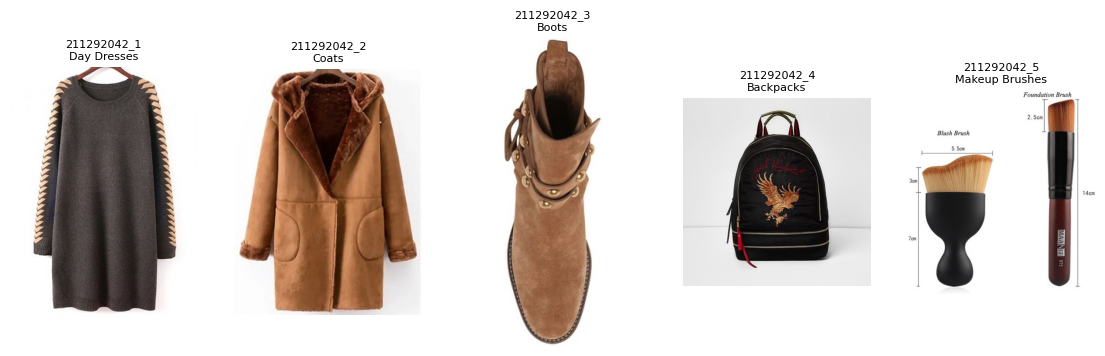

In [14]:
import matplotlib.pyplot as plt

sample = item_level_samples[0]

images = []
titles = []

for item in sample["items"]:
    row_index = item["row_index"]
    row = marqo_ds[row_index]

    image = row["image"].convert("RGB")
    images.append(image)

    title = f'{item["item_key"]}\n{item["category"]}'
    titles.append(title)

print("sample_id:", sample["sample_id"])
print("label:", sample["label"])
print("num_items:", sample["num_items"])
print("loaded images:", len(images))

plt.figure(figsize=(14, 4))

for i, image in enumerate(images):
    plt.subplot(1, len(images), i + 1)
    plt.imshow(image)
    plt.title(titles[i], fontsize=8)
    plt.axis("off")

plt.show()

CLIP 모델 로드

In [15]:
clip_model_name = "openai/clip-vit-base-patch32"

clip_model = CLIPModel.from_pretrained(clip_model_name).to(device)
clip_processor = CLIPProcessor.from_pretrained(clip_model_name)

clip_model.eval()

print("CLIP model loaded:", clip_model_name)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP model loaded: openai/clip-vit-base-patch32


item embedding 추출 테스트

In [17]:
with torch.no_grad():
    inputs = clip_processor(
        images=images,
        return_tensors="pt",
        padding=True
    ).to(device)

    outputs = clip_model.get_image_features(**inputs)

    # 정상적인 CLIPModel이면 outputs는 Tensor
    # 만약 VisionModel 계열 출력이면 pooler_output을 사용
    if isinstance(outputs, torch.Tensor):
        image_features = outputs
    elif hasattr(outputs, "image_embeds"):
        image_features = outputs.image_embeds
    elif hasattr(outputs, "pooler_output"):
        image_features = outputs.pooler_output
    else:
        raise TypeError(f"Unexpected CLIP output type: {type(outputs)}")

    # L2 normalization
    image_features = image_features / image_features.norm(dim=-1, keepdim=True)

print("item embedding shape:", image_features.shape)

outfit_embedding_mean = image_features.mean(dim=0)
outfit_embedding_mean = outfit_embedding_mean / outfit_embedding_mean.norm(dim=-1, keepdim=True)

print("outfit mean embedding shape:", outfit_embedding_mean.shape)

item embedding shape: torch.Size([5, 512])
outfit mean embedding shape: torch.Size([512])


여러 sample에서 embedding shape 확인

In [18]:
test_indices = [0, 1, 2]

for idx in test_indices:
    sample = item_level_samples[idx]

    sample_images = []

    for item in sample["items"]:
        row_index = item["row_index"]
        image = marqo_ds[row_index]["image"].convert("RGB")
        sample_images.append(image)

    with torch.no_grad():
        inputs = clip_processor(
            images=sample_images,
            return_tensors="pt",
            padding=True
        ).to(device)

        outputs = clip_model.get_image_features(**inputs)

        # CLIPModel이면 Tensor, VisionModel 계열이면 output 객체일 수 있음
        if isinstance(outputs, torch.Tensor):
            item_features = outputs
        elif hasattr(outputs, "image_embeds"):
            item_features = outputs.image_embeds
        elif hasattr(outputs, "pooler_output"):
            item_features = outputs.pooler_output
        else:
            raise TypeError(f"Unexpected CLIP output type: {type(outputs)}")

        item_features = item_features / item_features.norm(dim=-1, keepdim=True)

        outfit_feature = item_features.mean(dim=0)
        outfit_feature = outfit_feature / outfit_feature.norm(dim=-1, keepdim=True)

    print(
        f"idx={idx} | "
        f"sample_id={sample['sample_id']} | "
        f"label={sample['label']} | "
        f"num_items={sample['num_items']} | "
        f"item_features={tuple(item_features.shape)} | "
        f"outfit_feature={tuple(outfit_feature.shape)}"
    )

idx=0 | sample_id=252 | label=1 | num_items=5 | item_features=(5, 512) | outfit_feature=(512,)
idx=1 | sample_id=312 | label=1 | num_items=7 | item_features=(7, 512) | outfit_feature=(512,)
idx=2 | sample_id=1398 | label=0 | num_items=8 | item_features=(8, 512) | outfit_feature=(512,)


### Step 4 결과

Step 3에서 생성한 item-level metadata를 이용해 Marqo/polyvore 데이터셋에서 각 fashion item 이미지를 정상적으로 불러올 수 있음을 확인하였다.

선택한 여러 outfit sample에 대해 CLIP image encoder를 적용한 결과, 각 item 이미지는 512차원 embedding으로 변환되었고, item embedding들을 mean pooling하여 outfit-level embedding을 생성할 수 있었다.

예를 들어 item 수가 5개인 sample은 `(5, 512)` 형태의 item embedding을 생성하였고, mean pooling 후 `(512,)` 형태의 outfit embedding을 얻었다. 따라서 CLIP 기반 item-level feature fusion 실험을 진행하기 위한 입력 파이프라인이 정상적으로 동작함을 확인하였다.

### Step 5. 전체 outfit CLIP mean pooling embedding 추출

Step 4에서 sample 단위로 item image를 CLIP image encoder에 입력하고, item embedding을 mean pooling하여 outfit-level embedding을 만들 수 있음을 확인하였다.

이번 단계에서는 전체 2,420개 outfit sample에 대해 동일한 과정을 수행한다. 각 outfit을 구성하는 item 이미지를 Marqo/polyvore 데이터셋에서 불러오고, CLIP image encoder를 이용해 item별 512차원 embedding을 추출한다. 이후 item embedding을 평균 내어 outfit-level mean embedding을 생성한다.

생성된 outfit embedding, label, split, sample_id는 이후 MLP classifier 학습에 재사용할 수 있도록 `.pt` 파일로 저장한다.

전체 embedding 저장 경로 설정

In [19]:
from pathlib import Path
import torch
import json
import pandas as pd
from tqdm.auto import tqdm

PROJECT_ROOT = Path("/content/drive/MyDrive/aesthetic-ai")
EXP03_DIR = PROJECT_ROOT / "data" / "experiment_03_clip_item_fusion"

item_level_json_path = EXP03_DIR / "item_level_samples.json"

mean_embedding_path = EXP03_DIR / "clip_outfit_embeddings_mean.pt"
mean_summary_csv_path = EXP03_DIR / "clip_outfit_embeddings_mean_summary.csv"

print("item_level_json_path:", item_level_json_path.exists(), item_level_json_path)
print("mean_embedding_path:", mean_embedding_path)
print("mean_summary_csv_path:", mean_summary_csv_path)

with open(item_level_json_path, "r", encoding="utf-8") as f:
    item_level_samples = json.load(f)

print("num samples:", len(item_level_samples))

item_level_json_path: True /content/drive/MyDrive/aesthetic-ai/data/experiment_03_clip_item_fusion/item_level_samples.json
mean_embedding_path: /content/drive/MyDrive/aesthetic-ai/data/experiment_03_clip_item_fusion/clip_outfit_embeddings_mean.pt
mean_summary_csv_path: /content/drive/MyDrive/aesthetic-ai/data/experiment_03_clip_item_fusion/clip_outfit_embeddings_mean_summary.csv
num samples: 2420


전체 CLIP mean embedding 추출 및 저장

In [20]:
clip_model.eval()

all_embeddings = []
all_labels = []
all_splits = []
all_sample_ids = []
all_num_items = []

failed_samples = []

for sample in tqdm(item_level_samples, desc="Extracting CLIP mean embeddings"):
    try:
        sample_images = []

        for item in sample["items"]:
            row_index = item["row_index"]
            image = marqo_ds[row_index]["image"].convert("RGB")
            sample_images.append(image)

        with torch.no_grad():
            inputs = clip_processor(
                images=sample_images,
                return_tensors="pt",
                padding=True
            ).to(device)

            outputs = clip_model.get_image_features(**inputs)

            if isinstance(outputs, torch.Tensor):
                item_features = outputs
            elif hasattr(outputs, "image_embeds"):
                item_features = outputs.image_embeds
            elif hasattr(outputs, "pooler_output"):
                item_features = outputs.pooler_output
            else:
                raise TypeError(f"Unexpected CLIP output type: {type(outputs)}")

            item_features = item_features / item_features.norm(dim=-1, keepdim=True)

            outfit_feature = item_features.mean(dim=0)
            outfit_feature = outfit_feature / outfit_feature.norm(dim=-1, keepdim=True)

        all_embeddings.append(outfit_feature.cpu())
        all_labels.append(int(sample["label"]))
        all_splits.append(sample["split"])
        all_sample_ids.append(int(sample["sample_id"]))
        all_num_items.append(int(sample["num_items"]))

    except Exception as e:
        failed_samples.append({
            "sample_id": sample.get("sample_id"),
            "error": str(e)
        })

embeddings_tensor = torch.stack(all_embeddings)
labels_tensor = torch.tensor(all_labels, dtype=torch.long)

save_dict = {
    "embeddings": embeddings_tensor,
    "labels": labels_tensor,
    "splits": all_splits,
    "sample_ids": all_sample_ids,
    "num_items": all_num_items,
    "failed_samples": failed_samples,
    "model_name": clip_model_name,
    "pooling": "mean",
}

torch.save(save_dict, mean_embedding_path)

summary_df = pd.DataFrame({
    "sample_id": all_sample_ids,
    "split": all_splits,
    "label": all_labels,
    "num_items": all_num_items,
})

summary_df.to_csv(mean_summary_csv_path, index=False)

print("[Saved]")
print("pt:", mean_embedding_path)
print("csv:", mean_summary_csv_path)

print("\n[Embedding Result]")
print("embeddings shape:", embeddings_tensor.shape)
print("labels shape:", labels_tensor.shape)
print("saved samples:", len(all_sample_ids))
print("failed samples:", len(failed_samples))

print("\n[Split / Label Counts]")
print(pd.crosstab(summary_df["split"], summary_df["label"]))

if failed_samples:
    print("\n[Failed Samples]")
    print(failed_samples[:10])

Extracting CLIP mean embeddings:   0%|          | 0/2420 [00:00<?, ?it/s]

[Saved]
pt: /content/drive/MyDrive/aesthetic-ai/data/experiment_03_clip_item_fusion/clip_outfit_embeddings_mean.pt
csv: /content/drive/MyDrive/aesthetic-ai/data/experiment_03_clip_item_fusion/clip_outfit_embeddings_mean_summary.csv

[Embedding Result]
embeddings shape: torch.Size([2420, 512])
labels shape: torch.Size([2420])
saved samples: 2420
failed samples: 0

[Split / Label Counts]
label     0    1
split           
train  1025  911
val     256  228


저장된 embedding 파일 검증

In [21]:
loaded = torch.load(mean_embedding_path, map_location="cpu")

print("[Loaded keys]")
print(loaded.keys())

print("\n[Shapes]")
print("embeddings:", loaded["embeddings"].shape)
print("labels:", loaded["labels"].shape)
print("num splits:", len(loaded["splits"]))
print("num sample_ids:", len(loaded["sample_ids"]))
print("failed_samples:", len(loaded["failed_samples"]))

print("\n[Metadata]")
print("model_name:", loaded["model_name"])
print("pooling:", loaded["pooling"])

summary_df = pd.read_csv(mean_summary_csv_path)
print("\n[Summary CSV]")
print(summary_df.shape)
print(pd.crosstab(summary_df["split"], summary_df["label"]))
display(summary_df.head())

[Loaded keys]
dict_keys(['embeddings', 'labels', 'splits', 'sample_ids', 'num_items', 'failed_samples', 'model_name', 'pooling'])

[Shapes]
embeddings: torch.Size([2420, 512])
labels: torch.Size([2420])
num splits: 2420
num sample_ids: 2420
failed_samples: 0

[Metadata]
model_name: openai/clip-vit-base-patch32
pooling: mean

[Summary CSV]
(2420, 4)
label     0    1
split           
train  1025  911
val     256  228


,sample_id,split,label,num_items
0,252,train,1,5
1,312,train,1,7
2,1398,train,0,8
3,1698,train,0,4
4,1154,train,0,5


### Step 6. CLIP mean embedding 기반 MLP classifier 학습

Step 5에서 전체 2,420개 outfit sample에 대해 CLIP image encoder 기반 mean pooling embedding을 추출하였다. 각 outfit은 512차원 embedding으로 표현되며, label과 train/validation split 정보도 함께 저장되어 있다.

이번 단계에서는 저장된 CLIP mean embedding을 입력으로 사용하여 compatible/incompatible 이진 분류를 수행하는 MLP classifier를 학습한다.  
기존 Experiment 02의 ResNet18 grid baseline은 grid image를 직접 입력으로 사용했지만, 이번 실험은 각 fashion item을 개별적으로 CLIP embedding한 뒤 outfit 단위 feature로 결합한다는 점이 다르다.

성능은 validation accuracy, classification report, confusion matrix로 확인하고, Experiment 02의 ResNet18 grid baseline 성능인 68.18%와 비교한다.

저장된 CLIP mean embedding 로드

In [22]:
import torch
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/aesthetic-ai")
EXP03_DIR = PROJECT_ROOT / "data" / "experiment_03_clip_item_fusion"

mean_embedding_path = EXP03_DIR / "clip_outfit_embeddings_mean.pt"

data = torch.load(mean_embedding_path, map_location="cpu")

embeddings = data["embeddings"]
labels = data["labels"]
splits = data["splits"]
sample_ids = data["sample_ids"]

print("[Loaded]")
print("embeddings:", embeddings.shape)
print("labels:", labels.shape)
print("num splits:", len(splits))
print("num sample_ids:", len(sample_ids))
print("failed_samples:", len(data["failed_samples"]))
print("model_name:", data["model_name"])
print("pooling:", data["pooling"])

summary_df = pd.DataFrame({
    "sample_id": sample_ids,
    "split": splits,
    "label": labels.tolist(),
})

print("\n[Split / Label Counts]")
print(pd.crosstab(summary_df["split"], summary_df["label"]))
display(summary_df.head())

[Loaded]
embeddings: torch.Size([2420, 512])
labels: torch.Size([2420])
num splits: 2420
num sample_ids: 2420
failed_samples: 0
model_name: openai/clip-vit-base-patch32
pooling: mean

[Split / Label Counts]
label     0    1
split           
train  1025  911
val     256  228


,sample_id,split,label
0,252,train,1
1,312,train,1
2,1398,train,0
3,1698,train,0
4,1154,train,0


train / validation tensor 분리

In [23]:
import numpy as np

split_array = np.array(splits)

train_mask = split_array == "train"
val_mask = split_array == "val"

X_train = embeddings[train_mask]
y_train = labels[train_mask]

X_val = embeddings[val_mask]
y_val = labels[val_mask]

print("[Train / Val Split]")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("\n[Label Counts]")
print("train:", torch.bincount(y_train))
print("val:", torch.bincount(y_val))

[Train / Val Split]
X_train: torch.Size([1936, 512])
y_train: torch.Size([1936])
X_val: torch.Size([484, 512])
y_val: torch.Size([484])

[Label Counts]
train: tensor([1025,  911])
val: tensor([256, 228])


DataLoader 생성

In [24]:
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 32

train_dataset = TensorDataset(X_train.float(), y_train.long())
val_dataset = TensorDataset(X_val.float(), y_val.long())

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("train batches:", len(train_loader))
print("val batches:", len(val_loader))

train batches: 61
val batches: 16


MLP classifier 정의

In [25]:
import torch.nn as nn

class OutfitMLPClassifier(nn.Module):
    def __init__(self, input_dim=512, hidden_dim=256, dropout=0.3, num_classes=2):
        super().__init__()

        self.classifier = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.classifier(x)


device = "cuda" if torch.cuda.is_available() else "cpu"

model = OutfitMLPClassifier(
    input_dim=embeddings.shape[1],
    hidden_dim=256,
    dropout=0.3,
    num_classes=2
).to(device)

print(model)
print("device:", device)

OutfitMLPClassifier(
  (classifier): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=2, bias=True)
  )
)
device: cuda


학습 / 평가 함수 정의

In [26]:
from sklearn.metrics import accuracy_score

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    for batch_x, batch_y in dataloader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        logits = model(batch_x)
        loss = criterion(logits, batch_y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch_x.size(0)

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().tolist())
        all_labels.extend(batch_y.detach().cpu().tolist())

    avg_loss = total_loss / len(dataloader.dataset)
    acc = accuracy_score(all_labels, all_preds)

    return avg_loss, acc


def evaluate(model, dataloader, criterion, device):
    model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch_x, batch_y in dataloader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            logits = model(batch_x)
            loss = criterion(logits, batch_y)

            total_loss += loss.item() * batch_x.size(0)

            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.detach().cpu().tolist())
            all_labels.extend(batch_y.detach().cpu().tolist())

    avg_loss = total_loss / len(dataloader.dataset)
    acc = accuracy_score(all_labels, all_preds)

    return avg_loss, acc, all_labels, all_preds

MLP 학습 실행

In [27]:
import torch.optim as optim

EPOCHS = 30
LR = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

history = []

best_val_acc = 0.0
best_state_dict = None
best_epoch = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc, val_labels_epoch, val_preds_epoch = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
    })

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        best_state_dict = model.state_dict().copy()

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f}"
    )

print("\n[Best Result]")
print("best_epoch:", best_epoch)
print("best_val_acc:", round(best_val_acc, 4))

Epoch 01/30 | train_loss=0.6918 | train_acc=0.5227 | val_loss=0.6908 | val_acc=0.5331
Epoch 02/30 | train_loss=0.6889 | train_acc=0.5491 | val_loss=0.6890 | val_acc=0.5331
Epoch 03/30 | train_loss=0.6850 | train_acc=0.5496 | val_loss=0.6856 | val_acc=0.5475
Epoch 04/30 | train_loss=0.6778 | train_acc=0.5801 | val_loss=0.6826 | val_acc=0.5640
Epoch 05/30 | train_loss=0.6669 | train_acc=0.6085 | val_loss=0.6721 | val_acc=0.5992
Epoch 06/30 | train_loss=0.6525 | train_acc=0.6312 | val_loss=0.6649 | val_acc=0.5930
Epoch 07/30 | train_loss=0.6352 | train_acc=0.6555 | val_loss=0.6542 | val_acc=0.6116
Epoch 08/30 | train_loss=0.6221 | train_acc=0.6586 | val_loss=0.6551 | val_acc=0.6116
Epoch 09/30 | train_loss=0.6083 | train_acc=0.6684 | val_loss=0.6440 | val_acc=0.6322
Epoch 10/30 | train_loss=0.5930 | train_acc=0.6942 | val_loss=0.6370 | val_acc=0.6426
Epoch 11/30 | train_loss=0.5855 | train_acc=0.6968 | val_loss=0.6486 | val_acc=0.6178
Epoch 12/30 | train_loss=0.5890 | train_acc=0.6875 | v

best model 기준 최종 평가

In [28]:
from sklearn.metrics import classification_report, confusion_matrix

model.load_state_dict(best_state_dict)

val_loss, val_acc, val_labels, val_preds = evaluate(
    model,
    val_loader,
    criterion,
    device
)

print("[Final Validation Result]")
print("val_loss:", round(val_loss, 4))
print("val_acc:", round(val_acc, 4))

print("\n[Classification Report]")
print(classification_report(
    val_labels,
    val_preds,
    target_names=["incompatible", "compatible"],
    digits=4
))

print("\n[Confusion Matrix]")
cm = confusion_matrix(val_labels, val_preds)
print(cm)

[Final Validation Result]
val_loss: 0.588
val_acc: 0.6756

[Classification Report]
              precision    recall  f1-score   support

incompatible     0.7020    0.6719    0.6866       256
  compatible     0.6485    0.6798    0.6638       228

    accuracy                         0.6756       484
   macro avg     0.6753    0.6758    0.6752       484
weighted avg     0.6768    0.6756    0.6759       484


[Confusion Matrix]
[[172  84]
 [ 73 155]]


학습 history 저장

In [29]:
history_df = pd.DataFrame(history)

history_csv_path = EXP03_DIR / "clip_mean_mlp_training_history.csv"
result_json_path = EXP03_DIR / "clip_mean_mlp_result.json"
model_path = EXP03_DIR / "clip_mean_mlp_best_model.pt"

history_df.to_csv(history_csv_path, index=False)

result = {
    "model": "CLIP ViT-B/32 mean pooling + MLP classifier",
    "clip_model_name": data["model_name"],
    "pooling": data["pooling"],
    "input_dim": int(embeddings.shape[1]),
    "epochs": EPOCHS,
    "learning_rate": LR,
    "batch_size": BATCH_SIZE,
    "best_epoch": int(best_epoch),
    "best_val_acc": float(best_val_acc),
    "final_val_acc": float(val_acc),
    "confusion_matrix": cm.tolist(),
    "baseline_experiment_02_resnet18_grid_best_val_acc": 0.6818,
}

with open(result_json_path, "w", encoding="utf-8") as f:
    json.dump(result, f, ensure_ascii=False, indent=2)

torch.save(best_state_dict, model_path)

print("[Saved]")
print("history:", history_csv_path)
print("result:", result_json_path)
print("model:", model_path)

print("\n[Result]")
print(json.dumps(result, ensure_ascii=False, indent=2))

[Saved]
history: /content/drive/MyDrive/aesthetic-ai/data/experiment_03_clip_item_fusion/clip_mean_mlp_training_history.csv
result: /content/drive/MyDrive/aesthetic-ai/data/experiment_03_clip_item_fusion/clip_mean_mlp_result.json
model: /content/drive/MyDrive/aesthetic-ai/data/experiment_03_clip_item_fusion/clip_mean_mlp_best_model.pt

[Result]
{
  "model": "CLIP ViT-B/32 mean pooling + MLP classifier",
  "clip_model_name": "openai/clip-vit-base-patch32",
  "pooling": "mean",
  "input_dim": 512,
  "epochs": 30,
  "learning_rate": 0.001,
  "batch_size": 32,
  "best_epoch": 29,
  "best_val_acc": 0.6776859504132231,
  "final_val_acc": 0.6756198347107438,
  "confusion_matrix": [
    [
      172,
      84
    ],
    [
      73,
      155
    ]
  ],
  "baseline_experiment_02_resnet18_grid_best_val_acc": 0.6818
}


### Step 6 결과

CLIP mean pooling embedding을 입력으로 MLP classifier를 학습한 결과, best validation accuracy는 0.6777로 나타났다. 최종 평가 기준 validation accuracy는 0.6756이었다.

이는 Experiment 02의 ResNet18 grid baseline accuracy 0.6818보다 약간 낮은 결과이다. 따라서 단순 mean pooling 기반 CLIP item-level fusion은 전체 정확도 측면에서 grid baseline을 개선하지 못했다.

다만 confusion matrix를 비교하면 compatible class의 recall은 0.601에서 0.680으로 개선되었다. 반면 incompatible class의 recall은 0.754에서 0.672로 감소하였다. 즉, CLIP mean pooling 모델은 조화로운 outfit을 더 잘 잡는 방향으로 예측 성향이 이동했지만, 부조화 outfit을 compatible로 잘못 예측하는 경우가 증가하였다.

이 결과는 CLIP item embedding이 outfit compatibility 판단에 유용한 정보를 포함하고 있음을 보여주지만, 단순 평균 pooling만으로는 item 간 관계나 부조화 요소를 충분히 표현하기 어렵다는 한계를 나타낸다. 따라서 다음 단계에서는 mean pooling보다 더 풍부한 item-level fusion 방식이 필요하다.

### Step 7. CLIP mean + max pooling embedding 생성

Step 6에서 CLIP mean pooling embedding을 사용한 MLP classifier는 Experiment 02의 ResNet18 grid baseline을 명확히 넘지 못했다.  
Mean pooling은 outfit 전체의 평균적인 분위기를 표현할 수 있지만, 특정 item에서 강하게 드러나는 색감, 스타일, 형태적 특징이나 부조화 요소를 충분히 반영하기 어렵다.

따라서 이번 단계에서는 item embedding에 대해 mean pooling과 max pooling을 함께 적용한다.  
Mean pooling은 전체적인 outfit 조화를 나타내고, max pooling은 특정 item에서 강하게 나타나는 특징을 보존하는 역할을 한다.

각 outfit은 mean embedding 512차원과 max embedding 512차원을 연결하여 총 1024차원 feature로 표현된다.  
이 feature는 다음 단계에서 MLP classifier 학습에 사용한다.

mean + max embedding 저장 경로 설정

In [30]:
from pathlib import Path
import json
import torch
import pandas as pd
from tqdm.auto import tqdm

PROJECT_ROOT = Path("/content/drive/MyDrive/aesthetic-ai")
EXP03_DIR = PROJECT_ROOT / "data" / "experiment_03_clip_item_fusion"

item_level_json_path = EXP03_DIR / "item_level_samples.json"

meanmax_embedding_path = EXP03_DIR / "clip_outfit_embeddings_meanmax.pt"
meanmax_summary_csv_path = EXP03_DIR / "clip_outfit_embeddings_meanmax_summary.csv"

print("item_level_json_path:", item_level_json_path.exists(), item_level_json_path)
print("meanmax_embedding_path:", meanmax_embedding_path)
print("meanmax_summary_csv_path:", meanmax_summary_csv_path)

with open(item_level_json_path, "r", encoding="utf-8") as f:
    item_level_samples = json.load(f)

print("num samples:", len(item_level_samples))

item_level_json_path: True /content/drive/MyDrive/aesthetic-ai/data/experiment_03_clip_item_fusion/item_level_samples.json
meanmax_embedding_path: /content/drive/MyDrive/aesthetic-ai/data/experiment_03_clip_item_fusion/clip_outfit_embeddings_meanmax.pt
meanmax_summary_csv_path: /content/drive/MyDrive/aesthetic-ai/data/experiment_03_clip_item_fusion/clip_outfit_embeddings_meanmax_summary.csv
num samples: 2420


전체 CLIP mean + max embedding 추출 및 저장

In [31]:
clip_model.eval()

all_embeddings = []
all_labels = []
all_splits = []
all_sample_ids = []
all_num_items = []

failed_samples = []

for sample in tqdm(item_level_samples, desc="Extracting CLIP mean+max embeddings"):
    try:
        sample_images = []

        for item in sample["items"]:
            row_index = item["row_index"]
            image = marqo_ds[row_index]["image"].convert("RGB")
            sample_images.append(image)

        with torch.no_grad():
            inputs = clip_processor(
                images=sample_images,
                return_tensors="pt",
                padding=True
            ).to(device)

            outputs = clip_model.get_image_features(**inputs)

            if isinstance(outputs, torch.Tensor):
                item_features = outputs
            elif hasattr(outputs, "image_embeds"):
                item_features = outputs.image_embeds
            elif hasattr(outputs, "pooler_output"):
                item_features = outputs.pooler_output
            else:
                raise TypeError(f"Unexpected CLIP output type: {type(outputs)}")

            # item-level L2 normalization
            item_features = item_features / item_features.norm(dim=-1, keepdim=True)

            # mean pooling
            mean_feature = item_features.mean(dim=0)
            mean_feature = mean_feature / mean_feature.norm(dim=-1, keepdim=True)

            # max pooling
            max_feature = item_features.max(dim=0).values
            max_feature = max_feature / max_feature.norm(dim=-1, keepdim=True)

            # mean + max concat
            outfit_feature = torch.cat([mean_feature, max_feature], dim=0)
            outfit_feature = outfit_feature / outfit_feature.norm(dim=-1, keepdim=True)

        all_embeddings.append(outfit_feature.cpu())
        all_labels.append(int(sample["label"]))
        all_splits.append(sample["split"])
        all_sample_ids.append(int(sample["sample_id"]))
        all_num_items.append(int(sample["num_items"]))

    except Exception as e:
        failed_samples.append({
            "sample_id": sample.get("sample_id"),
            "error": str(e)
        })

embeddings_tensor = torch.stack(all_embeddings)
labels_tensor = torch.tensor(all_labels, dtype=torch.long)

save_dict = {
    "embeddings": embeddings_tensor,
    "labels": labels_tensor,
    "splits": all_splits,
    "sample_ids": all_sample_ids,
    "num_items": all_num_items,
    "failed_samples": failed_samples,
    "model_name": clip_model_name,
    "pooling": "mean_max_concat",
}

torch.save(save_dict, meanmax_embedding_path)

summary_df = pd.DataFrame({
    "sample_id": all_sample_ids,
    "split": all_splits,
    "label": all_labels,
    "num_items": all_num_items,
})

summary_df.to_csv(meanmax_summary_csv_path, index=False)

print("[Saved]")
print("pt:", meanmax_embedding_path)
print("csv:", meanmax_summary_csv_path)

print("\n[Embedding Result]")
print("embeddings shape:", embeddings_tensor.shape)
print("labels shape:", labels_tensor.shape)
print("saved samples:", len(all_sample_ids))
print("failed samples:", len(failed_samples))

print("\n[Split / Label Counts]")
print(pd.crosstab(summary_df["split"], summary_df["label"]))

if failed_samples:
    print("\n[Failed Samples]")
    print(failed_samples[:10])

Extracting CLIP mean+max embeddings:   0%|          | 0/2420 [00:00<?, ?it/s]

[Saved]
pt: /content/drive/MyDrive/aesthetic-ai/data/experiment_03_clip_item_fusion/clip_outfit_embeddings_meanmax.pt
csv: /content/drive/MyDrive/aesthetic-ai/data/experiment_03_clip_item_fusion/clip_outfit_embeddings_meanmax_summary.csv

[Embedding Result]
embeddings shape: torch.Size([2420, 1024])
labels shape: torch.Size([2420])
saved samples: 2420
failed samples: 0

[Split / Label Counts]
label     0    1
split           
train  1025  911
val     256  228


저장된 mean + max embedding 파일 검증

In [32]:
loaded_meanmax = torch.load(meanmax_embedding_path, map_location="cpu")

print("[Loaded keys]")
print(loaded_meanmax.keys())

print("\n[Shapes]")
print("embeddings:", loaded_meanmax["embeddings"].shape)
print("labels:", loaded_meanmax["labels"].shape)
print("num splits:", len(loaded_meanmax["splits"]))
print("num sample_ids:", len(loaded_meanmax["sample_ids"]))
print("failed_samples:", len(loaded_meanmax["failed_samples"]))

print("\n[Metadata]")
print("model_name:", loaded_meanmax["model_name"])
print("pooling:", loaded_meanmax["pooling"])

summary_df = pd.read_csv(meanmax_summary_csv_path)
print("\n[Summary CSV]")
print(summary_df.shape)
print(pd.crosstab(summary_df["split"], summary_df["label"]))
display(summary_df.head())

[Loaded keys]
dict_keys(['embeddings', 'labels', 'splits', 'sample_ids', 'num_items', 'failed_samples', 'model_name', 'pooling'])

[Shapes]
embeddings: torch.Size([2420, 1024])
labels: torch.Size([2420])
num splits: 2420
num sample_ids: 2420
failed_samples: 0

[Metadata]
model_name: openai/clip-vit-base-patch32
pooling: mean_max_concat

[Summary CSV]
(2420, 4)
label     0    1
split           
train  1025  911
val     256  228


,sample_id,split,label,num_items
0,252,train,1,5
1,312,train,1,7
2,1398,train,0,8
3,1698,train,0,4
4,1154,train,0,5


### Step 8. CLIP mean + max embedding 기반 MLP classifier 학습

Step 7에서 각 outfit의 item embedding에 대해 mean pooling과 max pooling을 함께 적용하여 1024차원 outfit feature를 생성하였다.

Mean pooling은 outfit 전체의 평균적인 조화와 분위기를 반영하고, max pooling은 특정 item에서 강하게 드러나는 특징을 보존한다.  
이번 단계에서는 이 1024차원 feature를 입력으로 MLP classifier를 학습하여 compatible/incompatible 분류 성능을 확인한다.

비교 기준은 Experiment 02의 ResNet18 grid baseline validation accuracy 0.6818과 Step 6의 CLIP mean pooling + MLP validation accuracy 0.6756이다.

mean + max embedding 로드

In [33]:
import torch
import pandas as pd
import numpy as np
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/aesthetic-ai")
EXP03_DIR = PROJECT_ROOT / "data" / "experiment_03_clip_item_fusion"

meanmax_embedding_path = EXP03_DIR / "clip_outfit_embeddings_meanmax.pt"

data_meanmax = torch.load(meanmax_embedding_path, map_location="cpu")

embeddings = data_meanmax["embeddings"]
labels = data_meanmax["labels"]
splits = data_meanmax["splits"]
sample_ids = data_meanmax["sample_ids"]

print("[Loaded]")
print("embeddings:", embeddings.shape)
print("labels:", labels.shape)
print("num splits:", len(splits))
print("num sample_ids:", len(sample_ids))
print("failed_samples:", len(data_meanmax["failed_samples"]))
print("model_name:", data_meanmax["model_name"])
print("pooling:", data_meanmax["pooling"])

summary_df = pd.DataFrame({
    "sample_id": sample_ids,
    "split": splits,
    "label": labels.tolist(),
})

print("\n[Split / Label Counts]")
print(pd.crosstab(summary_df["split"], summary_df["label"]))
display(summary_df.head())

[Loaded]
embeddings: torch.Size([2420, 1024])
labels: torch.Size([2420])
num splits: 2420
num sample_ids: 2420
failed_samples: 0
model_name: openai/clip-vit-base-patch32
pooling: mean_max_concat

[Split / Label Counts]
label     0    1
split           
train  1025  911
val     256  228


,sample_id,split,label
0,252,train,1
1,312,train,1
2,1398,train,0
3,1698,train,0
4,1154,train,0


train / validation 분리

In [34]:
split_array = np.array(splits)

train_mask = split_array == "train"
val_mask = split_array == "val"

X_train = embeddings[train_mask]
y_train = labels[train_mask]

X_val = embeddings[val_mask]
y_val = labels[val_mask]

print("[Train / Val Split]")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("\n[Label Counts]")
print("train:", torch.bincount(y_train))
print("val:", torch.bincount(y_val))

[Train / Val Split]
X_train: torch.Size([1936, 1024])
y_train: torch.Size([1936])
X_val: torch.Size([484, 1024])
y_val: torch.Size([484])

[Label Counts]
train: tensor([1025,  911])
val: tensor([256, 228])


DataLoader 생성

In [35]:
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 32

train_dataset = TensorDataset(X_train.float(), y_train.long())
val_dataset = TensorDataset(X_val.float(), y_val.long())

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("train batches:", len(train_loader))
print("val batches:", len(val_loader))

train batches: 61
val batches: 16


mean + max용 MLP classifier 정의

In [36]:
import torch.nn as nn

class OutfitMeanMaxMLPClassifier(nn.Module):
    def __init__(self, input_dim=1024, hidden_dim=256, dropout=0.4, num_classes=2):
        super().__init__()

        self.classifier = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.classifier(x)


device = "cuda" if torch.cuda.is_available() else "cpu"

model = OutfitMeanMaxMLPClassifier(
    input_dim=embeddings.shape[1],
    hidden_dim=256,
    dropout=0.4,
    num_classes=2
).to(device)

print(model)
print("device:", device)

OutfitMeanMaxMLPClassifier(
  (classifier): Sequential(
    (0): Linear(in_features=1024, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=256, out_features=2, bias=True)
  )
)
device: cuda


학습 / 평가 함수 정의

In [37]:
from sklearn.metrics import accuracy_score

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    for batch_x, batch_y in dataloader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        logits = model(batch_x)
        loss = criterion(logits, batch_y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch_x.size(0)

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().tolist())
        all_labels.extend(batch_y.detach().cpu().tolist())

    avg_loss = total_loss / len(dataloader.dataset)
    acc = accuracy_score(all_labels, all_preds)

    return avg_loss, acc


def evaluate(model, dataloader, criterion, device):
    model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch_x, batch_y in dataloader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            logits = model(batch_x)
            loss = criterion(logits, batch_y)

            total_loss += loss.item() * batch_x.size(0)

            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.detach().cpu().tolist())
            all_labels.extend(batch_y.detach().cpu().tolist())

    avg_loss = total_loss / len(dataloader.dataset)
    acc = accuracy_score(all_labels, all_preds)

    return avg_loss, acc, all_labels, all_preds

mean + max MLP 학습 실행

In [38]:
import torch.optim as optim

EPOCHS = 40
LR = 5e-4

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

history = []

best_val_acc = 0.0
best_state_dict = None
best_epoch = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc, val_labels_epoch, val_preds_epoch = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
    })

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f}"
    )

print("\n[Best Result]")
print("best_epoch:", best_epoch)
print("best_val_acc:", round(best_val_acc, 4))

Epoch 01/40 | train_loss=0.6911 | train_acc=0.5300 | val_loss=0.6895 | val_acc=0.5289
Epoch 02/40 | train_loss=0.6879 | train_acc=0.5460 | val_loss=0.6875 | val_acc=0.5289
Epoch 03/40 | train_loss=0.6843 | train_acc=0.5599 | val_loss=0.6852 | val_acc=0.5971
Epoch 04/40 | train_loss=0.6798 | train_acc=0.5754 | val_loss=0.6833 | val_acc=0.5496
Epoch 05/40 | train_loss=0.6748 | train_acc=0.5868 | val_loss=0.6786 | val_acc=0.5764
Epoch 06/40 | train_loss=0.6702 | train_acc=0.6002 | val_loss=0.6764 | val_acc=0.5764
Epoch 07/40 | train_loss=0.6603 | train_acc=0.6224 | val_loss=0.6717 | val_acc=0.5847
Epoch 08/40 | train_loss=0.6558 | train_acc=0.6302 | val_loss=0.6688 | val_acc=0.5992
Epoch 09/40 | train_loss=0.6484 | train_acc=0.6477 | val_loss=0.6656 | val_acc=0.5950
Epoch 10/40 | train_loss=0.6417 | train_acc=0.6477 | val_loss=0.6785 | val_acc=0.5599
Epoch 11/40 | train_loss=0.6406 | train_acc=0.6265 | val_loss=0.6593 | val_acc=0.6012
Epoch 12/40 | train_loss=0.6257 | train_acc=0.6586 | v

best model 기준 최종 평가

In [39]:
from sklearn.metrics import classification_report, confusion_matrix

model.load_state_dict(best_state_dict)
model.to(device)

val_loss, val_acc, val_labels, val_preds = evaluate(
    model,
    val_loader,
    criterion,
    device
)

print("[Final Validation Result]")
print("val_loss:", round(val_loss, 4))
print("val_acc:", round(val_acc, 4))

print("\n[Classification Report]")
print(classification_report(
    val_labels,
    val_preds,
    target_names=["incompatible", "compatible"],
    digits=4
))

print("\n[Confusion Matrix]")
cm = confusion_matrix(val_labels, val_preds)
print(cm)

[Final Validation Result]
val_loss: 0.6138
val_acc: 0.657

[Classification Report]
              precision    recall  f1-score   support

incompatible     0.6907    0.6367    0.6626       256
  compatible     0.6250    0.6798    0.6513       228

    accuracy                         0.6570       484
   macro avg     0.6578    0.6583    0.6569       484
weighted avg     0.6597    0.6570    0.6573       484


[Confusion Matrix]
[[163  93]
 [ 73 155]]


mean + max MLP 결과 저장

In [40]:
import json

history_df = pd.DataFrame(history)

history_csv_path = EXP03_DIR / "clip_meanmax_mlp_training_history.csv"
result_json_path = EXP03_DIR / "clip_meanmax_mlp_result.json"
model_path = EXP03_DIR / "clip_meanmax_mlp_best_model.pt"

history_df.to_csv(history_csv_path, index=False)

result = {
    "model": "CLIP ViT-B/32 mean+max pooling + MLP classifier",
    "clip_model_name": data_meanmax["model_name"],
    "pooling": data_meanmax["pooling"],
    "input_dim": int(embeddings.shape[1]),
    "epochs": EPOCHS,
    "learning_rate": LR,
    "batch_size": BATCH_SIZE,
    "best_epoch": int(best_epoch),
    "best_val_acc": float(best_val_acc),
    "final_val_acc": float(val_acc),
    "confusion_matrix": cm.tolist(),
    "baseline_experiment_02_resnet18_grid_best_val_acc": 0.6818,
    "clip_mean_mlp_best_val_acc": 0.6777,
    "clip_mean_mlp_final_val_acc": 0.6756,
}

with open(result_json_path, "w", encoding="utf-8") as f:
    json.dump(result, f, ensure_ascii=False, indent=2)

torch.save(best_state_dict, model_path)

print("[Saved]")
print("history:", history_csv_path)
print("result:", result_json_path)
print("model:", model_path)

print("\n[Result]")
print(json.dumps(result, ensure_ascii=False, indent=2))

[Saved]
history: /content/drive/MyDrive/aesthetic-ai/data/experiment_03_clip_item_fusion/clip_meanmax_mlp_training_history.csv
result: /content/drive/MyDrive/aesthetic-ai/data/experiment_03_clip_item_fusion/clip_meanmax_mlp_result.json
model: /content/drive/MyDrive/aesthetic-ai/data/experiment_03_clip_item_fusion/clip_meanmax_mlp_best_model.pt

[Result]
{
  "model": "CLIP ViT-B/32 mean+max pooling + MLP classifier",
  "clip_model_name": "openai/clip-vit-base-patch32",
  "pooling": "mean_max_concat",
  "input_dim": 1024,
  "epochs": 40,
  "learning_rate": 0.0005,
  "batch_size": 32,
  "best_epoch": 29,
  "best_val_acc": 0.6570247933884298,
  "final_val_acc": 0.6570247933884298,
  "confusion_matrix": [
    [
      163,
      93
    ],
    [
      73,
      155
    ]
  ],
  "baseline_experiment_02_resnet18_grid_best_val_acc": 0.6818,
  "clip_mean_mlp_best_val_acc": 0.6777,
  "clip_mean_mlp_final_val_acc": 0.6756
}


### Step 8 결과

CLIP mean + max pooling embedding을 입력으로 MLP classifier를 학습한 결과, best validation accuracy는 0.6570으로 나타났다. 이는 Step 6의 CLIP mean pooling 결과와 Experiment 02의 ResNet18 grid baseline보다 낮은 성능이다.

Mean + max pooling은 mean pooling보다 더 많은 item-level 정보를 포함하도록 설계되었지만, feature dimension이 512에서 1024로 증가하면서 현재 데이터 규모에서는 과적합 위험이 커졌다. 또한 max pooling은 특정 item에서 강하게 나타나는 특징을 보존하지만, 착장 조화 판단에서는 일부 item의 강한 특징이 전체 compatibility 판단을 흐릴 수 있다.

따라서 단순히 pooling feature를 확장하는 방식만으로는 성능 개선에 한계가 있음을 확인하였다. 이후 실험에서는 mean pooling feature를 유지하되, MLP classifier의 regularization과 학습 설정을 조정하여 더 안정적인 baseline을 확인한다.

### Step 9. CLIP mean embedding 기반 MLP 튜닝

Step 6에서 CLIP mean pooling embedding 기반 MLP classifier는 validation accuracy 0.6756, best validation accuracy 0.6777을 기록하였다. 이는 Experiment 02의 ResNet18 grid baseline 0.6818과 거의 유사하지만, 명확한 성능 개선은 아니었다.

Step 8에서 mean + max pooling feature를 사용했을 때는 feature dimension 증가와 max pooling의 영향으로 validation 성능이 오히려 하락하였다.  
따라서 이번 단계에서는 다시 mean pooling feature를 사용하되, MLP classifier의 hidden dimension, dropout, learning rate, weight decay를 조정하여 과적합을 줄이고 validation 성능을 안정화한다.

이번 실험은 새로운 feature 구조를 제안하기보다, CLIP mean embedding baseline의 학습 설정을 더 보수적으로 조정하는 튜닝 실험이다.

CLIP mean embedding 다시 로드

In [41]:
import torch
import pandas as pd
import numpy as np
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/aesthetic-ai")
EXP03_DIR = PROJECT_ROOT / "data" / "experiment_03_clip_item_fusion"

mean_embedding_path = EXP03_DIR / "clip_outfit_embeddings_mean.pt"

data_mean = torch.load(mean_embedding_path, map_location="cpu")

embeddings = data_mean["embeddings"]
labels = data_mean["labels"]
splits = data_mean["splits"]
sample_ids = data_mean["sample_ids"]

print("[Loaded]")
print("embeddings:", embeddings.shape)
print("labels:", labels.shape)
print("num splits:", len(splits))
print("num sample_ids:", len(sample_ids))
print("failed_samples:", len(data_mean["failed_samples"]))
print("model_name:", data_mean["model_name"])
print("pooling:", data_mean["pooling"])

summary_df = pd.DataFrame({
    "sample_id": sample_ids,
    "split": splits,
    "label": labels.tolist(),
})

print("\n[Split / Label Counts]")
print(pd.crosstab(summary_df["split"], summary_df["label"]))
display(summary_df.head())

[Loaded]
embeddings: torch.Size([2420, 512])
labels: torch.Size([2420])
num splits: 2420
num sample_ids: 2420
failed_samples: 0
model_name: openai/clip-vit-base-patch32
pooling: mean

[Split / Label Counts]
label     0    1
split           
train  1025  911
val     256  228


,sample_id,split,label
0,252,train,1
1,312,train,1
2,1398,train,0
3,1698,train,0
4,1154,train,0


train / validation 분리

In [42]:
split_array = np.array(splits)

train_mask = split_array == "train"
val_mask = split_array == "val"

X_train = embeddings[train_mask]
y_train = labels[train_mask]

X_val = embeddings[val_mask]
y_val = labels[val_mask]

print("[Train / Val Split]")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("\n[Label Counts]")
print("train:", torch.bincount(y_train))
print("val:", torch.bincount(y_val))

[Train / Val Split]
X_train: torch.Size([1936, 512])
y_train: torch.Size([1936])
X_val: torch.Size([484, 512])
y_val: torch.Size([484])

[Label Counts]
train: tensor([1025,  911])
val: tensor([256, 228])


DataLoader 생성

In [43]:
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 32

train_dataset = TensorDataset(X_train.float(), y_train.long())
val_dataset = TensorDataset(X_val.float(), y_val.long())

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("train batches:", len(train_loader))
print("val batches:", len(val_loader))

train batches: 61
val batches: 16


튜닝용 단순 MLP 정의

In [44]:
import torch.nn as nn

class TunedMeanMLPClassifier(nn.Module):
    def __init__(self, input_dim=512, hidden_dim=128, dropout=0.5, num_classes=2):
        super().__init__()

        self.classifier = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.classifier(x)


device = "cuda" if torch.cuda.is_available() else "cpu"

model = TunedMeanMLPClassifier(
    input_dim=embeddings.shape[1],
    hidden_dim=128,
    dropout=0.5,
    num_classes=2
).to(device)

print(model)
print("device:", device)

TunedMeanMLPClassifier(
  (classifier): Sequential(
    (0): Linear(in_features=512, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=128, out_features=2, bias=True)
  )
)
device: cuda


학습 / 평가 함수 정의

In [45]:
from sklearn.metrics import accuracy_score

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    for batch_x, batch_y in dataloader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        logits = model(batch_x)
        loss = criterion(logits, batch_y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch_x.size(0)

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().tolist())
        all_labels.extend(batch_y.detach().cpu().tolist())

    avg_loss = total_loss / len(dataloader.dataset)
    acc = accuracy_score(all_labels, all_preds)

    return avg_loss, acc


def evaluate(model, dataloader, criterion, device):
    model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch_x, batch_y in dataloader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            logits = model(batch_x)
            loss = criterion(logits, batch_y)

            total_loss += loss.item() * batch_x.size(0)

            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.detach().cpu().tolist())
            all_labels.extend(batch_y.detach().cpu().tolist())

    avg_loss = total_loss / len(dataloader.dataset)
    acc = accuracy_score(all_labels, all_preds)

    return avg_loss, acc, all_labels, all_preds

Early stopping 포함 튜닝 학습

In [46]:
import torch.optim as optim

EPOCHS = 80
LR = 3e-4
WEIGHT_DECAY = 1e-3
PATIENCE = 12

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

history = []

best_val_acc = 0.0
best_val_loss = float("inf")
best_state_dict = None
best_epoch = 0

patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc, val_labels_epoch, val_preds_epoch = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
    })

    improved = val_acc > best_val_acc

    if improved:
        best_val_acc = val_acc
        best_val_loss = val_loss
        best_epoch = epoch
        best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | "
        f"patience={patience_counter}/{PATIENCE}"
    )

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}")
        break

print("\n[Best Result]")
print("best_epoch:", best_epoch)
print("best_val_loss:", round(best_val_loss, 4))
print("best_val_acc:", round(best_val_acc, 4))

Epoch 01/80 | train_loss=0.6925 | train_acc=0.5114 | val_loss=0.6909 | val_acc=0.5289 | patience=0/12
Epoch 02/80 | train_loss=0.6909 | train_acc=0.5310 | val_loss=0.6904 | val_acc=0.5289 | patience=1/12
Epoch 03/80 | train_loss=0.6903 | train_acc=0.5315 | val_loss=0.6900 | val_acc=0.5289 | patience=2/12
Epoch 04/80 | train_loss=0.6895 | train_acc=0.5320 | val_loss=0.6897 | val_acc=0.5289 | patience=3/12
Epoch 05/80 | train_loss=0.6875 | train_acc=0.5320 | val_loss=0.6893 | val_acc=0.5331 | patience=0/12
Epoch 06/80 | train_loss=0.6887 | train_acc=0.5403 | val_loss=0.6884 | val_acc=0.5331 | patience=1/12
Epoch 07/80 | train_loss=0.6876 | train_acc=0.5356 | val_loss=0.6883 | val_acc=0.5434 | patience=0/12
Epoch 08/80 | train_loss=0.6856 | train_acc=0.5434 | val_loss=0.6877 | val_acc=0.5393 | patience=1/12
Epoch 09/80 | train_loss=0.6842 | train_acc=0.5708 | val_loss=0.6867 | val_acc=0.5434 | patience=2/12
Epoch 10/80 | train_loss=0.6828 | train_acc=0.5625 | val_loss=0.6857 | val_acc=0.5

best model 기준 최종 평가

In [47]:
from sklearn.metrics import classification_report, confusion_matrix

model.load_state_dict(best_state_dict)
model.to(device)

val_loss, val_acc, val_labels, val_preds = evaluate(
    model,
    val_loader,
    criterion,
    device
)

print("[Final Validation Result]")
print("val_loss:", round(val_loss, 4))
print("val_acc:", round(val_acc, 4))

print("\n[Classification Report]")
print(classification_report(
    val_labels,
    val_preds,
    target_names=["incompatible", "compatible"],
    digits=4
))

print("\n[Confusion Matrix]")
cm = confusion_matrix(val_labels, val_preds)
print(cm)

[Final Validation Result]
val_loss: 0.6802
val_acc: 0.6157

[Classification Report]
              precision    recall  f1-score   support

incompatible     0.6067    0.7773    0.6815       256
  compatible     0.6346    0.4342    0.5156       228

    accuracy                         0.6157       484
   macro avg     0.6207    0.6058    0.5986       484
weighted avg     0.6199    0.6157    0.6034       484


[Confusion Matrix]
[[199  57]
 [129  99]]


튜닝 결과 저장

In [48]:
import json

history_df = pd.DataFrame(history)

history_csv_path = EXP03_DIR / "clip_mean_mlp_tuned_training_history.csv"
result_json_path = EXP03_DIR / "clip_mean_mlp_tuned_result.json"
model_path = EXP03_DIR / "clip_mean_mlp_tuned_best_model.pt"

history_df.to_csv(history_csv_path, index=False)

result = {
    "model": "CLIP ViT-B/32 mean pooling + tuned MLP classifier",
    "clip_model_name": data_mean["model_name"],
    "pooling": data_mean["pooling"],
    "input_dim": int(embeddings.shape[1]),
    "hidden_dim": 128,
    "dropout": 0.5,
    "epochs": EPOCHS,
    "learning_rate": LR,
    "weight_decay": WEIGHT_DECAY,
    "batch_size": BATCH_SIZE,
    "early_stopping_patience": PATIENCE,
    "best_epoch": int(best_epoch),
    "best_val_acc": float(best_val_acc),
    "final_val_acc": float(val_acc),
    "confusion_matrix": cm.tolist(),
    "baseline_experiment_02_resnet18_grid_best_val_acc": 0.6818,
    "clip_mean_mlp_best_val_acc": 0.6777,
    "clip_mean_mlp_final_val_acc": 0.6756,
    "clip_meanmax_mlp_best_val_acc": 0.6570,
}

with open(result_json_path, "w", encoding="utf-8") as f:
    json.dump(result, f, ensure_ascii=False, indent=2)

torch.save(best_state_dict, model_path)

print("[Saved]")
print("history:", history_csv_path)
print("result:", result_json_path)
print("model:", model_path)

print("\n[Result]")
print(json.dumps(result, ensure_ascii=False, indent=2))

[Saved]
history: /content/drive/MyDrive/aesthetic-ai/data/experiment_03_clip_item_fusion/clip_mean_mlp_tuned_training_history.csv
result: /content/drive/MyDrive/aesthetic-ai/data/experiment_03_clip_item_fusion/clip_mean_mlp_tuned_result.json
model: /content/drive/MyDrive/aesthetic-ai/data/experiment_03_clip_item_fusion/clip_mean_mlp_tuned_best_model.pt

[Result]
{
  "model": "CLIP ViT-B/32 mean pooling + tuned MLP classifier",
  "clip_model_name": "openai/clip-vit-base-patch32",
  "pooling": "mean",
  "input_dim": 512,
  "hidden_dim": 128,
  "dropout": 0.5,
  "epochs": 80,
  "learning_rate": 0.0003,
  "weight_decay": 0.001,
  "batch_size": 32,
  "early_stopping_patience": 12,
  "best_epoch": 16,
  "best_val_acc": 0.6157024793388429,
  "final_val_acc": 0.6157024793388429,
  "confusion_matrix": [
    [
      199,
      57
    ],
    [
      129,
      99
    ]
  ],
  "baseline_experiment_02_resnet18_grid_best_val_acc": 0.6818,
  "clip_mean_mlp_best_val_acc": 0.6777,
  "clip_mean_mlp_fina

### Step 9 결과

CLIP mean pooling embedding에 대해 더 작은 hidden dimension, 높은 dropout, 강한 weight decay를 적용한 tuned MLP를 학습하였다.  
그 결과 best validation accuracy는 0.6157로 나타났으며, Step 6의 기본 MLP 결과보다 크게 낮았다.

이는 현재 설정에서 regularization이 과하게 적용되어 모델이 충분히 학습하지 못했을 가능성을 보여준다.  
따라서 단순히 MLP classifier의 regularization을 강화하는 방식은 Experiment 03의 성능 개선 방향으로 적절하지 않다고 판단하였다.

현재까지 가장 안정적인 CLIP 기반 결과는 Step 6의 mean pooling + 기본 MLP이며, best validation accuracy는 0.6777이다.

## Experiment 03 방향 재정의

지금까지 Experiment 03에서는 CLIP image encoder를 이용해 각 fashion item 이미지를 embedding하고, outfit 단위 feature로 결합하는 방식을 실험하였다.

먼저 item embedding을 단순 mean pooling하여 MLP classifier를 학습하였고, 이후 mean + max pooling 및 MLP regularization 튜닝을 시도하였다. 그러나 세 방식 모두 Experiment 02의 ResNet18 grid baseline을 안정적으로 넘지는 못했다.

이 결과는 CLIP item embedding 자체가 outfit compatibility 판단에 사용할 수 있는 정보를 포함하고 있더라도, 단순 pooling 방식만으로는 착장 조화에 필요한 item 간 관계를 충분히 표현하기 어렵다는 점을 보여준다.

착장 조화는 단순한 이미지 미감 분류 문제가 아니라, 색감 조화, item 간 스타일 일관성, 재질과 패턴의 조합, 카테고리별 역할, 특정 item의 시각적 비중 등이 함께 작용하는 문제이다.

따라서 이후 Experiment 03은 단순 pooling 기반 feature 결합에서 벗어나, item 간 관계를 명시적으로 반영하는 방향으로 확장한다. 우선 CLIP item embedding 간 pairwise cosine similarity를 계산하여 outfit 내부 item들의 관계 통계값을 만들고, 이를 기존 CLIP mean embedding과 결합하여 compatibility classifier를 다시 학습한다.

### 현재까지의 Experiment 03 결과

| 실험 | 입력 feature | Best validation accuracy | 해석 |
|---|---:|---:|---|
| Experiment 02 baseline | ResNet18 grid image | 0.6818 | grid 기반 착장 조화 baseline |
| Step 6 | CLIP mean pooling + MLP | 0.6777 | grid baseline과 유사하지만 개선은 아님 |
| Step 8 | CLIP mean + max pooling + MLP | 0.6570 | feature 차원 증가 후 성능 하락 |
| Step 9 | CLIP mean pooling + tuned MLP | 0.6157 | regularization이 과해 성능 하락 |

현재까지 가장 안정적인 CLIP 기반 결과는 Step 6의 mean pooling + 기본 MLP이다.  
그러나 단순 pooling 방식은 item 간 관계를 직접 표현하지 못하므로, 다음 단계에서는 pairwise relation feature를 추가한다.

### Step 10. Pairwise item relation feature 생성

지금까지의 CLIP item-level 실험에서는 outfit을 구성하는 item embedding들을 단순 pooling하여 outfit feature를 만들었다.  
그러나 mean pooling은 outfit의 전체적인 분위기는 표현할 수 있지만, item 간의 관계를 직접적으로 반영하지 못한다.

착장 조화는 개별 item의 품질보다 item 사이의 관계에서 결정되는 경우가 많다. 예를 들어 상의와 하의의 색감, 신발과 전체 스타일의 일치, 가방이나 액세서리의 이질감은 item 간 비교를 통해 더 잘 드러난다.

따라서 이번 단계에서는 각 outfit 내부의 item embedding들 사이의 cosine similarity를 계산하고, pairwise similarity의 평균, 최솟값, 최댓값, 표준편차, 범위 등을 relation feature로 생성한다.  
이 relation feature를 기존 CLIP mean embedding과 결합하여, item-level 의미 정보와 item 간 관계 정보를 함께 포함하는 feature를 만든다.

Pairwise relation feature 저장 경로 설정

In [49]:
from pathlib import Path
import json
import torch
import pandas as pd
import numpy as np
from tqdm.auto import tqdm

PROJECT_ROOT = Path("/content/drive/MyDrive/aesthetic-ai")
EXP03_DIR = PROJECT_ROOT / "data" / "experiment_03_clip_item_fusion"

item_level_json_path = EXP03_DIR / "item_level_samples.json"

pairwise_embedding_path = EXP03_DIR / "clip_outfit_embeddings_mean_pairwise.pt"
pairwise_summary_csv_path = EXP03_DIR / "clip_outfit_embeddings_mean_pairwise_summary.csv"

print("item_level_json_path:", item_level_json_path.exists(), item_level_json_path)
print("pairwise_embedding_path:", pairwise_embedding_path)
print("pairwise_summary_csv_path:", pairwise_summary_csv_path)

with open(item_level_json_path, "r", encoding="utf-8") as f:
    item_level_samples = json.load(f)

print("num samples:", len(item_level_samples))

item_level_json_path: True /content/drive/MyDrive/aesthetic-ai/data/experiment_03_clip_item_fusion/item_level_samples.json
pairwise_embedding_path: /content/drive/MyDrive/aesthetic-ai/data/experiment_03_clip_item_fusion/clip_outfit_embeddings_mean_pairwise.pt
pairwise_summary_csv_path: /content/drive/MyDrive/aesthetic-ai/data/experiment_03_clip_item_fusion/clip_outfit_embeddings_mean_pairwise_summary.csv
num samples: 2420


Pairwise relation feature 추출 함수 정의

In [50]:
def extract_pairwise_relation_stats(item_features: torch.Tensor) -> torch.Tensor:
    """
    item_features: shape = (num_items, embedding_dim)
    이미 L2 normalization된 item embedding이라고 가정한다.
    """

    num_items = item_features.shape[0]

    # cosine similarity matrix
    sim_matrix = item_features @ item_features.T

    # diagonal 제외한 pairwise similarity만 사용
    mask = ~torch.eye(num_items, dtype=torch.bool, device=item_features.device)
    pairwise_sims = sim_matrix[mask]

    mean_sim = pairwise_sims.mean()
    min_sim = pairwise_sims.min()
    max_sim = pairwise_sims.max()
    std_sim = pairwise_sims.std(unbiased=False)
    range_sim = max_sim - min_sim

    # item 개수도 relation 구조의 일부로 사용
    # 4~8개 범위를 대략 0~1 근처로 맞추기 위해 10으로 나눔
    num_items_feature = torch.tensor(
        float(num_items) / 10.0,
        device=item_features.device
    )

    relation_stats = torch.stack([
        mean_sim,
        min_sim,
        max_sim,
        std_sim,
        range_sim,
        num_items_feature
    ])

    return relation_stats

전체 outfit의 mean + pairwise feature 생성 및 저장

In [51]:
clip_model.eval()

all_embeddings = []
all_mean_embeddings = []
all_relation_stats = []

all_labels = []
all_splits = []
all_sample_ids = []
all_num_items = []

failed_samples = []

for sample in tqdm(item_level_samples, desc="Extracting CLIP mean + pairwise relation features"):
    try:
        sample_images = []

        for item in sample["items"]:
            row_index = item["row_index"]
            image = marqo_ds[row_index]["image"].convert("RGB")
            sample_images.append(image)

        with torch.no_grad():
            inputs = clip_processor(
                images=sample_images,
                return_tensors="pt",
                padding=True
            ).to(device)

            outputs = clip_model.get_image_features(**inputs)

            if isinstance(outputs, torch.Tensor):
                item_features = outputs
            elif hasattr(outputs, "image_embeds"):
                item_features = outputs.image_embeds
            elif hasattr(outputs, "pooler_output"):
                item_features = outputs.pooler_output
            else:
                raise TypeError(f"Unexpected CLIP output type: {type(outputs)}")

            # item-level L2 normalization
            item_features = item_features / item_features.norm(dim=-1, keepdim=True)

            # outfit mean embedding
            mean_feature = item_features.mean(dim=0)
            mean_feature = mean_feature / mean_feature.norm(dim=-1, keepdim=True)

            # pairwise relation stats
            relation_stats = extract_pairwise_relation_stats(item_features)

            # mean embedding + relation stats
            outfit_feature = torch.cat([mean_feature, relation_stats], dim=0)

        all_embeddings.append(outfit_feature.cpu())
        all_mean_embeddings.append(mean_feature.cpu())
        all_relation_stats.append(relation_stats.cpu())

        all_labels.append(int(sample["label"]))
        all_splits.append(sample["split"])
        all_sample_ids.append(int(sample["sample_id"]))
        all_num_items.append(int(sample["num_items"]))

    except Exception as e:
        failed_samples.append({
            "sample_id": sample.get("sample_id"),
            "error": str(e)
        })

embeddings_tensor = torch.stack(all_embeddings)
mean_embeddings_tensor = torch.stack(all_mean_embeddings)
relation_stats_tensor = torch.stack(all_relation_stats)
labels_tensor = torch.tensor(all_labels, dtype=torch.long)

save_dict = {
    "embeddings": embeddings_tensor,
    "mean_embeddings": mean_embeddings_tensor,
    "relation_stats": relation_stats_tensor,
    "labels": labels_tensor,
    "splits": all_splits,
    "sample_ids": all_sample_ids,
    "num_items": all_num_items,
    "failed_samples": failed_samples,
    "model_name": clip_model_name,
    "feature_type": "clip_mean_plus_pairwise_relation_stats",
    "relation_stat_names": [
        "pairwise_mean_similarity",
        "pairwise_min_similarity",
        "pairwise_max_similarity",
        "pairwise_std_similarity",
        "pairwise_range_similarity",
        "num_items_scaled"
    ],
}

torch.save(save_dict, pairwise_embedding_path)

summary_df = pd.DataFrame({
    "sample_id": all_sample_ids,
    "split": all_splits,
    "label": all_labels,
    "num_items": all_num_items,
    "pairwise_mean_similarity": relation_stats_tensor[:, 0].tolist(),
    "pairwise_min_similarity": relation_stats_tensor[:, 1].tolist(),
    "pairwise_max_similarity": relation_stats_tensor[:, 2].tolist(),
    "pairwise_std_similarity": relation_stats_tensor[:, 3].tolist(),
    "pairwise_range_similarity": relation_stats_tensor[:, 4].tolist(),
    "num_items_scaled": relation_stats_tensor[:, 5].tolist(),
})

summary_df.to_csv(pairwise_summary_csv_path, index=False)

print("[Saved]")
print("pt:", pairwise_embedding_path)
print("csv:", pairwise_summary_csv_path)

print("\n[Embedding Result]")
print("embeddings shape:", embeddings_tensor.shape)
print("mean_embeddings shape:", mean_embeddings_tensor.shape)
print("relation_stats shape:", relation_stats_tensor.shape)
print("labels shape:", labels_tensor.shape)
print("saved samples:", len(all_sample_ids))
print("failed samples:", len(failed_samples))

print("\n[Split / Label Counts]")
print(pd.crosstab(summary_df["split"], summary_df["label"]))

print("\n[Relation Stats Summary]")
display(summary_df[[
    "pairwise_mean_similarity",
    "pairwise_min_similarity",
    "pairwise_max_similarity",
    "pairwise_std_similarity",
    "pairwise_range_similarity",
    "num_items_scaled"
]].describe())

if failed_samples:
    print("\n[Failed Samples]")
    print(failed_samples[:10])

Extracting CLIP mean + pairwise relation features:   0%|          | 0/2420 [00:00<?, ?it/s]

[Saved]
pt: /content/drive/MyDrive/aesthetic-ai/data/experiment_03_clip_item_fusion/clip_outfit_embeddings_mean_pairwise.pt
csv: /content/drive/MyDrive/aesthetic-ai/data/experiment_03_clip_item_fusion/clip_outfit_embeddings_mean_pairwise_summary.csv

[Embedding Result]
embeddings shape: torch.Size([2420, 518])
mean_embeddings shape: torch.Size([2420, 512])
relation_stats shape: torch.Size([2420, 6])
labels shape: torch.Size([2420])
saved samples: 2420
failed samples: 0

[Split / Label Counts]
label     0    1
split           
train  1025  911
val     256  228

[Relation Stats Summary]


,pairwise_mean_similarity,pairwise_min_similarity,pairwise_max_similarity,pairwise_std_similarity,pairwise_range_similarity,num_items_scaled
count,2420.000000,2420.000000,2420.000000,2420.000000,2420.000000,2420.000000
mean,0.681275,0.570772,0.801035,0.067986,0.230262,0.571198
std,0.054328,0.088054,0.055929,0.026652,0.091095,0.142850
min,0.463377,0.247752,0.592280,0.009776,0.025440,0.400000
25%,0.647417,0.515873,0.764026,0.049290,0.164058,0.400000
50%,0.683980,0.577429,0.802502,0.064528,0.220863,0.500000
75%,0.717449,0.633272,0.837547,0.081937,0.288860,0.700000
max,0.956510,0.931683,1.000000,0.178466,0.567075,0.800000


저장된 pairwise feature 파일 검증

In [52]:
loaded_pairwise = torch.load(pairwise_embedding_path, map_location="cpu")

print("[Loaded keys]")
print(loaded_pairwise.keys())

print("\n[Shapes]")
print("embeddings:", loaded_pairwise["embeddings"].shape)
print("mean_embeddings:", loaded_pairwise["mean_embeddings"].shape)
print("relation_stats:", loaded_pairwise["relation_stats"].shape)
print("labels:", loaded_pairwise["labels"].shape)
print("num splits:", len(loaded_pairwise["splits"]))
print("num sample_ids:", len(loaded_pairwise["sample_ids"]))
print("failed_samples:", len(loaded_pairwise["failed_samples"]))

print("\n[Metadata]")
print("model_name:", loaded_pairwise["model_name"])
print("feature_type:", loaded_pairwise["feature_type"])
print("relation_stat_names:", loaded_pairwise["relation_stat_names"])

summary_df = pd.read_csv(pairwise_summary_csv_path)
print("\n[Summary CSV]")
print(summary_df.shape)
print(pd.crosstab(summary_df["split"], summary_df["label"]))
display(summary_df.head())

[Loaded keys]
dict_keys(['embeddings', 'mean_embeddings', 'relation_stats', 'labels', 'splits', 'sample_ids', 'num_items', 'failed_samples', 'model_name', 'feature_type', 'relation_stat_names'])

[Shapes]
embeddings: torch.Size([2420, 518])
mean_embeddings: torch.Size([2420, 512])
relation_stats: torch.Size([2420, 6])
labels: torch.Size([2420])
num splits: 2420
num sample_ids: 2420
failed_samples: 0

[Metadata]
model_name: openai/clip-vit-base-patch32
feature_type: clip_mean_plus_pairwise_relation_stats
relation_stat_names: ['pairwise_mean_similarity', 'pairwise_min_similarity', 'pairwise_max_similarity', 'pairwise_std_similarity', 'pairwise_range_similarity', 'num_items_scaled']

[Summary CSV]
(2420, 10)
label     0    1
split           
train  1025  911
val     256  228


,sample_id,split,label,num_items,pairwise_mean_similarity,pairwise_min_similarity,pairwise_max_similarity,pairwise_std_similarity,pairwise_range_similarity,num_items_scaled
0,252,train,1,5,0.681371,0.558400,0.839808,0.091388,0.281408,0.5
1,312,train,1,7,0.579614,0.327443,0.738448,0.116281,0.411005,0.7
2,1398,train,0,8,0.629724,0.446301,0.811449,0.082953,0.365148,0.8
3,1698,train,0,4,0.704028,0.624802,0.805553,0.062429,0.180752,0.4
4,1154,train,0,5,0.657825,0.554546,0.754049,0.072819,0.199503,0.5


### Step 11. CLIP mean + pairwise relation feature 기반 MLP classifier 학습

Step 10에서 각 outfit의 CLIP mean embedding에 item 간 pairwise cosine similarity 통계 feature를 결합하였다.  
기존 CLIP mean embedding은 outfit의 전체적인 평균 분위기를 표현하지만, item 간 관계를 직접적으로 반영하지 못한다는 한계가 있었다.

이번 단계에서는 512차원 CLIP mean embedding에 pairwise relation stats 6개를 추가한 518차원 feature를 입력으로 MLP classifier를 학습한다.  
pairwise relation stats는 outfit 내부 item embedding들 간 cosine similarity의 평균, 최솟값, 최댓값, 표준편차, 범위, item 개수 정보를 포함한다.

비교 기준은 Experiment 02의 ResNet18 grid baseline validation accuracy 0.6818과 Step 6의 CLIP mean pooling + MLP best validation accuracy 0.6777이다.

mean + pairwise feature 로드

In [53]:
import torch
import pandas as pd
import numpy as np
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/aesthetic-ai")
EXP03_DIR = PROJECT_ROOT / "data" / "experiment_03_clip_item_fusion"

pairwise_embedding_path = EXP03_DIR / "clip_outfit_embeddings_mean_pairwise.pt"

data_pairwise = torch.load(pairwise_embedding_path, map_location="cpu")

embeddings = data_pairwise["embeddings"]
labels = data_pairwise["labels"]
splits = data_pairwise["splits"]
sample_ids = data_pairwise["sample_ids"]
relation_stats = data_pairwise["relation_stats"]

print("[Loaded]")
print("embeddings:", embeddings.shape)
print("relation_stats:", relation_stats.shape)
print("labels:", labels.shape)
print("num splits:", len(splits))
print("num sample_ids:", len(sample_ids))
print("failed_samples:", len(data_pairwise["failed_samples"]))
print("model_name:", data_pairwise["model_name"])
print("feature_type:", data_pairwise["feature_type"])
print("relation_stat_names:", data_pairwise["relation_stat_names"])

summary_df = pd.DataFrame({
    "sample_id": sample_ids,
    "split": splits,
    "label": labels.tolist(),
})

print("\n[Split / Label Counts]")
print(pd.crosstab(summary_df["split"], summary_df["label"]))
display(summary_df.head())

[Loaded]
embeddings: torch.Size([2420, 518])
relation_stats: torch.Size([2420, 6])
labels: torch.Size([2420])
num splits: 2420
num sample_ids: 2420
failed_samples: 0
model_name: openai/clip-vit-base-patch32
feature_type: clip_mean_plus_pairwise_relation_stats
relation_stat_names: ['pairwise_mean_similarity', 'pairwise_min_similarity', 'pairwise_max_similarity', 'pairwise_std_similarity', 'pairwise_range_similarity', 'num_items_scaled']

[Split / Label Counts]
label     0    1
split           
train  1025  911
val     256  228


,sample_id,split,label
0,252,train,1
1,312,train,1
2,1398,train,0
3,1698,train,0
4,1154,train,0


train / validation 분리

In [54]:
split_array = np.array(splits)

train_mask = split_array == "train"
val_mask = split_array == "val"

X_train = embeddings[train_mask]
y_train = labels[train_mask]

X_val = embeddings[val_mask]
y_val = labels[val_mask]

print("[Train / Val Split]")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("\n[Label Counts]")
print("train:", torch.bincount(y_train))
print("val:", torch.bincount(y_val))

[Train / Val Split]
X_train: torch.Size([1936, 518])
y_train: torch.Size([1936])
X_val: torch.Size([484, 518])
y_val: torch.Size([484])

[Label Counts]
train: tensor([1025,  911])
val: tensor([256, 228])


DataLoader 생성

In [55]:
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 32

train_dataset = TensorDataset(X_train.float(), y_train.long())
val_dataset = TensorDataset(X_val.float(), y_val.long())

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("train batches:", len(train_loader))
print("val batches:", len(val_loader))

train batches: 61
val batches: 16


Pairwise feature용 MLP classifier 정의

In [56]:
import torch.nn as nn

class PairwiseMLPClassifier(nn.Module):
    def __init__(self, input_dim=518, hidden_dim=256, dropout=0.3, num_classes=2):
        super().__init__()

        self.classifier = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.classifier(x)


device = "cuda" if torch.cuda.is_available() else "cpu"

model = PairwiseMLPClassifier(
    input_dim=embeddings.shape[1],
    hidden_dim=256,
    dropout=0.3,
    num_classes=2
).to(device)

print(model)
print("device:", device)

PairwiseMLPClassifier(
  (classifier): Sequential(
    (0): Linear(in_features=518, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=2, bias=True)
  )
)
device: cuda


학습 / 평가 함수 정의

In [57]:
from sklearn.metrics import accuracy_score

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    for batch_x, batch_y in dataloader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        logits = model(batch_x)
        loss = criterion(logits, batch_y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch_x.size(0)

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().tolist())
        all_labels.extend(batch_y.detach().cpu().tolist())

    avg_loss = total_loss / len(dataloader.dataset)
    acc = accuracy_score(all_labels, all_preds)

    return avg_loss, acc


def evaluate(model, dataloader, criterion, device):
    model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch_x, batch_y in dataloader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            logits = model(batch_x)
            loss = criterion(logits, batch_y)

            total_loss += loss.item() * batch_x.size(0)

            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.detach().cpu().tolist())
            all_labels.extend(batch_y.detach().cpu().tolist())

    avg_loss = total_loss / len(dataloader.dataset)
    acc = accuracy_score(all_labels, all_preds)

    return avg_loss, acc, all_labels, all_preds

mean + pairwise MLP 학습 실행

In [58]:
import torch.optim as optim

EPOCHS = 40
LR = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=1e-4
)

history = []

best_val_acc = 0.0
best_val_loss = float("inf")
best_state_dict = None
best_epoch = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc, val_labels_epoch, val_preds_epoch = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
    })

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_val_loss = val_loss
        best_epoch = epoch
        best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f}"
    )

print("\n[Best Result]")
print("best_epoch:", best_epoch)
print("best_val_loss:", round(best_val_loss, 4))
print("best_val_acc:", round(best_val_acc, 4))

Epoch 01/40 | train_loss=0.6925 | train_acc=0.5284 | val_loss=0.6894 | val_acc=0.5331
Epoch 02/40 | train_loss=0.6878 | train_acc=0.5522 | val_loss=0.6875 | val_acc=0.5331
Epoch 03/40 | train_loss=0.6804 | train_acc=0.5863 | val_loss=0.6824 | val_acc=0.5517
Epoch 04/40 | train_loss=0.6716 | train_acc=0.6095 | val_loss=0.6765 | val_acc=0.6012
Epoch 05/40 | train_loss=0.6589 | train_acc=0.6250 | val_loss=0.6698 | val_acc=0.5992
Epoch 06/40 | train_loss=0.6481 | train_acc=0.6167 | val_loss=0.6607 | val_acc=0.6012
Epoch 07/40 | train_loss=0.6346 | train_acc=0.6524 | val_loss=0.6545 | val_acc=0.6012
Epoch 08/40 | train_loss=0.6236 | train_acc=0.6679 | val_loss=0.6426 | val_acc=0.6302
Epoch 09/40 | train_loss=0.6046 | train_acc=0.6978 | val_loss=0.6347 | val_acc=0.6281
Epoch 10/40 | train_loss=0.5941 | train_acc=0.6860 | val_loss=0.6306 | val_acc=0.6426
Epoch 11/40 | train_loss=0.5843 | train_acc=0.6947 | val_loss=0.6232 | val_acc=0.6426
Epoch 12/40 | train_loss=0.5710 | train_acc=0.7066 | v

best model 기준 최종 평가

In [59]:
from sklearn.metrics import classification_report, confusion_matrix

model.load_state_dict(best_state_dict)
model.to(device)

val_loss, val_acc, val_labels, val_preds = evaluate(
    model,
    val_loader,
    criterion,
    device
)

print("[Final Validation Result]")
print("val_loss:", round(val_loss, 4))
print("val_acc:", round(val_acc, 4))

print("\n[Classification Report]")
print(classification_report(
    val_labels,
    val_preds,
    target_names=["incompatible", "compatible"],
    digits=4
))

print("\n[Confusion Matrix]")
cm = confusion_matrix(val_labels, val_preds)
print(cm)

[Final Validation Result]
val_loss: 0.5651
val_acc: 0.7128

[Classification Report]
              precision    recall  f1-score   support

incompatible     0.7112    0.7695    0.7392       256
  compatible     0.7150    0.6491    0.6805       228

    accuracy                         0.7128       484
   macro avg     0.7131    0.7093    0.7098       484
weighted avg     0.7130    0.7128    0.7115       484


[Confusion Matrix]
[[197  59]
 [ 80 148]]


mean + pairwise MLP 결과 저장

In [60]:
import json

history_df = pd.DataFrame(history)

history_csv_path = EXP03_DIR / "clip_mean_pairwise_mlp_training_history.csv"
result_json_path = EXP03_DIR / "clip_mean_pairwise_mlp_result.json"
model_path = EXP03_DIR / "clip_mean_pairwise_mlp_best_model.pt"

history_df.to_csv(history_csv_path, index=False)

result = {
    "model": "CLIP ViT-B/32 mean pooling + pairwise relation stats + MLP classifier",
    "clip_model_name": data_pairwise["model_name"],
    "feature_type": data_pairwise["feature_type"],
    "input_dim": int(embeddings.shape[1]),
    "relation_stat_names": data_pairwise["relation_stat_names"],
    "epochs": EPOCHS,
    "learning_rate": LR,
    "weight_decay": 1e-4,
    "batch_size": BATCH_SIZE,
    "best_epoch": int(best_epoch),
    "best_val_acc": float(best_val_acc),
    "final_val_acc": float(val_acc),
    "final_val_loss": float(val_loss),
    "confusion_matrix": cm.tolist(),
    "baseline_experiment_02_resnet18_grid_best_val_acc": 0.6818,
    "clip_mean_mlp_best_val_acc": 0.6777,
    "clip_mean_mlp_final_val_acc": 0.6756,
    "clip_meanmax_mlp_best_val_acc": 0.6570,
    "clip_mean_tuned_mlp_best_val_acc": 0.6157,
}

with open(result_json_path, "w", encoding="utf-8") as f:
    json.dump(result, f, ensure_ascii=False, indent=2)

torch.save(best_state_dict, model_path)

print("[Saved]")
print("history:", history_csv_path)
print("result:", result_json_path)
print("model:", model_path)

print("\n[Result]")
print(json.dumps(result, ensure_ascii=False, indent=2))

[Saved]
history: /content/drive/MyDrive/aesthetic-ai/data/experiment_03_clip_item_fusion/clip_mean_pairwise_mlp_training_history.csv
result: /content/drive/MyDrive/aesthetic-ai/data/experiment_03_clip_item_fusion/clip_mean_pairwise_mlp_result.json
model: /content/drive/MyDrive/aesthetic-ai/data/experiment_03_clip_item_fusion/clip_mean_pairwise_mlp_best_model.pt

[Result]
{
  "model": "CLIP ViT-B/32 mean pooling + pairwise relation stats + MLP classifier",
  "clip_model_name": "openai/clip-vit-base-patch32",
  "feature_type": "clip_mean_plus_pairwise_relation_stats",
  "input_dim": 518,
  "relation_stat_names": [
    "pairwise_mean_similarity",
    "pairwise_min_similarity",
    "pairwise_max_similarity",
    "pairwise_std_similarity",
    "pairwise_range_similarity",
    "num_items_scaled"
  ],
  "epochs": 40,
  "learning_rate": 0.001,
  "weight_decay": 0.0001,
  "batch_size": 32,
  "best_epoch": 40,
  "best_val_acc": 0.7128099173553719,
  "final_val_acc": 0.7128099173553719,
  "final_

### Step 11 결과

CLIP mean embedding에 pairwise item relation stats를 결합한 feature로 MLP classifier를 학습한 결과, validation accuracy는 0.7128로 나타났다. 이는 Experiment 02의 ResNet18 grid baseline accuracy 0.6818과 Step 6의 CLIP mean pooling baseline accuracy 0.6777을 모두 상회하는 결과이다.

Confusion matrix는 `[[197, 59], [80, 148]]`로 나타났다. Incompatible class의 recall은 0.7695, compatible class의 recall은 0.6491이었다. Experiment 02 baseline과 비교했을 때 incompatible recall과 compatible recall이 모두 개선되었다.

이 결과는 착장 조화 판단에서 개별 item embedding의 평균 표현만으로는 부족하며, item 간 관계 정보를 명시적으로 반영하는 pairwise relation feature가 compatibility 분류 성능 향상에 효과적임을 보여준다.

### Step 12. Experiment 03 현재 결과 정리

Experiment 03에서는 grid image 방식의 한계를 보완하기 위해 CLIP image encoder 기반 item-level feature fusion을 실험하였다.

먼저 각 outfit을 구성하는 fashion item 이미지를 CLIP image encoder로 embedding하고, item embedding을 mean pooling하여 outfit-level feature를 생성하였다. 그러나 단순 mean pooling 방식은 Experiment 02의 ResNet18 grid baseline을 넘지 못했다.

이후 mean + max pooling, regularization을 강화한 tuned MLP를 실험했지만 성능은 오히려 하락하였다. 이는 단순 pooling 확장이나 classifier 튜닝만으로는 착장 조화 판단에 필요한 item 간 관계를 충분히 반영하기 어렵다는 점을 보여준다.

반면 CLIP mean embedding에 pairwise item relation stats를 결합한 feature는 validation accuracy 0.7128을 기록하였다. 이는 Experiment 02의 ResNet18 grid baseline 0.6818보다 약 3.1%p 높은 결과이다.

따라서 현재까지의 Experiment 03 대표 결과는 `CLIP mean embedding + pairwise relation stats + MLP classifier`이다.

Experiment 03 결과 비교표 저장

In [61]:
import pandas as pd
import json
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/aesthetic-ai")
EXP03_DIR = PROJECT_ROOT / "data" / "experiment_03_clip_item_fusion"

experiment_results = [
    {
        "experiment": "Experiment 02 baseline",
        "feature": "ResNet18 grid image",
        "input_dim": "-",
        "best_val_acc": 0.6818,
        "final_val_acc": 0.6818,
        "macro_f1": None,
        "confusion_matrix": "[[193, 63], [91, 137]]",
        "interpretation": "Grid image 기반 착장 조화 baseline"
    },
    {
        "experiment": "Experiment 03 - Step 6",
        "feature": "CLIP mean pooling + MLP",
        "input_dim": 512,
        "best_val_acc": 0.6777,
        "final_val_acc": 0.6756,
        "macro_f1": 0.6752,
        "confusion_matrix": "[[172, 84], [73, 155]]",
        "interpretation": "CLIP item embedding은 유효하지만 단순 mean pooling은 grid baseline을 넘지 못함"
    },
    {
        "experiment": "Experiment 03 - Step 8",
        "feature": "CLIP mean + max pooling + MLP",
        "input_dim": 1024,
        "best_val_acc": 0.6570,
        "final_val_acc": None,
        "macro_f1": None,
        "confusion_matrix": None,
        "interpretation": "Feature 차원 증가와 max pooling 영향으로 성능 하락"
    },
    {
        "experiment": "Experiment 03 - Step 9",
        "feature": "CLIP mean pooling + tuned MLP",
        "input_dim": 512,
        "best_val_acc": 0.6157,
        "final_val_acc": None,
        "macro_f1": None,
        "confusion_matrix": None,
        "interpretation": "강한 regularization으로 인해 언더피팅 가능성 확인"
    },
    {
        "experiment": "Experiment 03 - Step 11",
        "feature": "CLIP mean pooling + pairwise relation stats + MLP",
        "input_dim": 518,
        "best_val_acc": 0.7128,
        "final_val_acc": 0.7128,
        "macro_f1": 0.7098,
        "confusion_matrix": "[[197, 59], [80, 148]]",
        "interpretation": "Item 간 관계 정보를 반영하여 grid baseline 대비 약 3.1%p 개선"
    }
]

results_df = pd.DataFrame(experiment_results)

summary_csv_path = EXP03_DIR / "experiment_03_result_summary.csv"
summary_json_path = EXP03_DIR / "experiment_03_result_summary.json"

results_df.to_csv(summary_csv_path, index=False)

with open(summary_json_path, "w", encoding="utf-8") as f:
    json.dump(experiment_results, f, ensure_ascii=False, indent=2)

print("[Saved]")
print("csv:", summary_csv_path)
print("json:", summary_json_path)

display(results_df)

[Saved]
csv: /content/drive/MyDrive/aesthetic-ai/data/experiment_03_clip_item_fusion/experiment_03_result_summary.csv
json: /content/drive/MyDrive/aesthetic-ai/data/experiment_03_clip_item_fusion/experiment_03_result_summary.json


,experiment,feature,input_dim,best_val_acc,final_val_acc,macro_f1,confusion_matrix,interpretation
0,Experiment 02 baseline,ResNet18 grid image,-,0.6818,0.6818,NaN,"[[193, 63], [91, 137]]",Grid image 기반 착장 조화 baseline
1,Experiment 03 - Step 6,CLIP mean pooling + MLP,512,0.6777,0.6756,0.6752,"[[172, 84], [73, 155]]",CLIP item embedding은 유효하지만 단순 mean pooling은 gr...
2,Experiment 03 - Step 8,CLIP mean + max pooling + MLP,1024,0.6570,NaN,NaN,None,Feature 차원 증가와 max pooling 영향으로 성능 하락
3,Experiment 03 - Step 9,CLIP mean pooling + tuned MLP,512,0.6157,NaN,NaN,None,강한 regularization으로 인해 언더피팅 가능성 확인
4,Experiment 03 - Step 11,CLIP mean pooling + pairwise relation stats + MLP,518,0.7128,0.7128,0.7098,"[[197, 59], [80, 148]]",Item 간 관계 정보를 반영하여 grid baseline 대비 약 3.1%p 개선


### Experiment 03 현재 결론

현재까지의 실험 결과, 단순 CLIP mean pooling은 grid image baseline과 유사한 성능을 보였지만 명확한 개선은 만들지 못했다.  
Mean + max pooling이나 강한 regularization을 적용한 MLP 튜닝은 오히려 성능을 하락시켰다.

반면 pairwise item relation stats를 추가한 feature는 validation accuracy 0.7128을 기록하며 Experiment 02 baseline 0.6818을 넘어섰다.  
이는 착장 조화 판단에서 item 자체의 시각적 의미뿐 아니라 item 간 관계 정보가 중요하다는 점을 보여준다.

따라서 Experiment 03의 현재 대표 모델은 `CLIP ViT-B/32 mean pooling + pairwise relation stats + MLP classifier`로 설정한다.

### Step 13. Color harmony feature 생성

Step 11에서 CLIP mean embedding에 pairwise item relation stats를 추가한 결과, validation accuracy가 0.7128로 향상되었다.  
이는 착장 조화 판단에서 item 간 관계 정보가 중요하다는 것을 보여준다.

그러나 착장 조화는 item embedding 간 의미적 관계뿐 아니라 색감 조화의 영향을 크게 받는다.  
특히 전체 outfit의 색상 수, 색상 간 거리, 채도와 명도의 분산, item 간 색상 차이는 사용자가 체감하는 조화감에 직접적으로 영향을 줄 수 있다.

이번 단계에서는 각 item image에서 평균 RGB와 HSV 색상 정보를 추출하고, outfit 단위로 색감 통계 feature를 생성한다.  
생성된 color harmony feature는 기존 CLIP mean + pairwise relation feature와 결합하여 다음 classifier 학습에 사용한다.

Color feature 저장 경로 설정

In [62]:
from pathlib import Path
import json
import torch
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
from PIL import Image
import colorsys

PROJECT_ROOT = Path("/content/drive/MyDrive/aesthetic-ai")
EXP03_DIR = PROJECT_ROOT / "data" / "experiment_03_clip_item_fusion"

item_level_json_path = EXP03_DIR / "item_level_samples.json"
pairwise_embedding_path = EXP03_DIR / "clip_outfit_embeddings_mean_pairwise.pt"

color_feature_path = EXP03_DIR / "clip_outfit_embeddings_mean_pairwise_color.pt"
color_summary_csv_path = EXP03_DIR / "clip_outfit_embeddings_mean_pairwise_color_summary.csv"

print("item_level_json_path:", item_level_json_path.exists(), item_level_json_path)
print("pairwise_embedding_path:", pairwise_embedding_path.exists(), pairwise_embedding_path)
print("color_feature_path:", color_feature_path)
print("color_summary_csv_path:", color_summary_csv_path)

with open(item_level_json_path, "r", encoding="utf-8") as f:
    item_level_samples = json.load(f)

pairwise_data = torch.load(pairwise_embedding_path, map_location="cpu")

print("num samples:", len(item_level_samples))
print("pairwise embeddings:", pairwise_data["embeddings"].shape)
print("pairwise labels:", pairwise_data["labels"].shape)

item_level_json_path: True /content/drive/MyDrive/aesthetic-ai/data/experiment_03_clip_item_fusion/item_level_samples.json
pairwise_embedding_path: True /content/drive/MyDrive/aesthetic-ai/data/experiment_03_clip_item_fusion/clip_outfit_embeddings_mean_pairwise.pt
color_feature_path: /content/drive/MyDrive/aesthetic-ai/data/experiment_03_clip_item_fusion/clip_outfit_embeddings_mean_pairwise_color.pt
color_summary_csv_path: /content/drive/MyDrive/aesthetic-ai/data/experiment_03_clip_item_fusion/clip_outfit_embeddings_mean_pairwise_color_summary.csv
num samples: 2420
pairwise embeddings: torch.Size([2420, 518])
pairwise labels: torch.Size([2420])


item image 색상 feature 추출 함수 정의

In [63]:
def extract_item_color_feature(image: Image.Image) -> np.ndarray:
    """
    item image 1장에서 평균 RGB/HSV 색상 feature를 추출한다.
    반환 shape: (6,)
    [mean_r, mean_g, mean_b, mean_h, mean_s, mean_v]
    """

    image = image.convert("RGB").resize((128, 128))

    arr = np.asarray(image).astype(np.float32) / 255.0

    # 흰 배경 영향 줄이기
    # RGB가 모두 0.95 이상인 거의 흰색 픽셀은 제외
    white_mask = np.all(arr > 0.95, axis=-1)
    valid_pixels = arr[~white_mask]

    # 혹시 전부 흰색으로 판단되면 전체 픽셀 사용
    if len(valid_pixels) == 0:
        valid_pixels = arr.reshape(-1, 3)

    mean_rgb = valid_pixels.mean(axis=0)

    hsv_pixels = np.array([
        colorsys.rgb_to_hsv(float(r), float(g), float(b))
        for r, g, b in valid_pixels
    ], dtype=np.float32)

    mean_hsv = hsv_pixels.mean(axis=0)

    return np.concatenate([mean_rgb, mean_hsv], axis=0)


def extract_outfit_color_stats(item_color_features: np.ndarray) -> np.ndarray:
    """
    item_color_features shape: (num_items, 6)
    각 item의 [mean_r, mean_g, mean_b, mean_h, mean_s, mean_v]를 이용해
    outfit-level color harmony stats를 만든다.

    반환 shape: (10,)
    """

    rgb = item_color_features[:, :3]
    hsv = item_color_features[:, 3:]

    # item 간 RGB 거리
    pairwise_distances = []

    num_items = rgb.shape[0]

    for i in range(num_items):
        for j in range(i + 1, num_items):
            dist = np.linalg.norm(rgb[i] - rgb[j])
            pairwise_distances.append(dist)

    pairwise_distances = np.array(pairwise_distances, dtype=np.float32)

    if len(pairwise_distances) == 0:
        pairwise_distances = np.array([0.0], dtype=np.float32)

    rgb_mean = rgb.mean(axis=0)
    hsv_mean = hsv.mean(axis=0)
    hsv_std = hsv.std(axis=0)

    color_stats = np.array([
        pairwise_distances.mean(),   # item 간 평균 색상 거리
        pairwise_distances.min(),    # 가장 가까운 색상 거리
        pairwise_distances.max(),    # 가장 먼 색상 거리
        pairwise_distances.std(),    # 색상 거리 분산
        hsv_mean[0],                 # 평균 hue
        hsv_mean[1],                 # 평균 saturation
        hsv_mean[2],                 # 평균 value
        hsv_std[0],                  # hue 다양도
        hsv_std[1],                  # saturation 다양도
        hsv_std[2],                  # value 다양도
    ], dtype=np.float32)

    return color_stats

sample 1개 색감 feature 테스트

In [64]:
sample = item_level_samples[0]

item_color_features = []

for item in sample["items"]:
    row_index = item["row_index"]
    image = marqo_ds[row_index]["image"].convert("RGB")
    color_feature = extract_item_color_feature(image)
    item_color_features.append(color_feature)

item_color_features = np.stack(item_color_features)
outfit_color_stats = extract_outfit_color_stats(item_color_features)

print("sample_id:", sample["sample_id"])
print("num_items:", sample["num_items"])
print("item_color_features shape:", item_color_features.shape)
print("outfit_color_stats shape:", outfit_color_stats.shape)
print("outfit_color_stats:")
print(outfit_color_stats)

sample_id: 252
num_items: 5
item_color_features shape: (5, 6)
outfit_color_stats shape: (10,)
outfit_color_stats:
[0.29446048 0.03543203 0.6136417  0.18193585 0.11868747 0.30202556
 0.51167905 0.04959568 0.19750668 0.11524914]


전체 outfit color feature 생성 및 pairwise feature와 결합

In [65]:
base_embeddings = pairwise_data["embeddings"]
labels = pairwise_data["labels"]
splits = pairwise_data["splits"]
sample_ids = pairwise_data["sample_ids"]
num_items_list = pairwise_data["num_items"]

all_color_stats = []
failed_samples = []

for idx, sample in enumerate(tqdm(item_level_samples, desc="Extracting color harmony features")):
    try:
        item_color_features = []

        for item in sample["items"]:
            row_index = item["row_index"]
            image = marqo_ds[row_index]["image"].convert("RGB")
            color_feature = extract_item_color_feature(image)
            item_color_features.append(color_feature)

        item_color_features = np.stack(item_color_features)
        outfit_color_stats = extract_outfit_color_stats(item_color_features)

        all_color_stats.append(torch.tensor(outfit_color_stats, dtype=torch.float32))

    except Exception as e:
        failed_samples.append({
            "index": idx,
            "sample_id": sample.get("sample_id"),
            "error": str(e)
        })

if failed_samples:
    print("[Warning] Failed samples exist:", len(failed_samples))
    print(failed_samples[:5])

color_stats_tensor = torch.stack(all_color_stats)

# color stats scale이 CLIP feature와 다를 수 있으므로 feature별 표준화
color_mean = color_stats_tensor.mean(dim=0, keepdim=True)
color_std = color_stats_tensor.std(dim=0, keepdim=True)
color_stats_norm = (color_stats_tensor - color_mean) / (color_std + 1e-8)

combined_embeddings = torch.cat([base_embeddings, color_stats_norm], dim=1)

save_dict = {
    "embeddings": combined_embeddings,
    "base_embeddings": base_embeddings,
    "color_stats": color_stats_tensor,
    "color_stats_normalized": color_stats_norm,
    "color_mean": color_mean,
    "color_std": color_std,
    "labels": labels,
    "splits": splits,
    "sample_ids": sample_ids,
    "num_items": num_items_list,
    "failed_samples": failed_samples,
    "model_name": pairwise_data["model_name"],
    "feature_type": "clip_mean_pairwise_plus_color_stats",
    "base_feature_type": pairwise_data["feature_type"],
    "relation_stat_names": pairwise_data["relation_stat_names"],
    "color_stat_names": [
        "rgb_pairwise_mean_distance",
        "rgb_pairwise_min_distance",
        "rgb_pairwise_max_distance",
        "rgb_pairwise_std_distance",
        "mean_hue",
        "mean_saturation",
        "mean_value",
        "std_hue",
        "std_saturation",
        "std_value"
    ],
}

torch.save(save_dict, color_feature_path)

summary_df = pd.DataFrame({
    "sample_id": sample_ids,
    "split": splits,
    "label": labels.tolist(),
    "num_items": num_items_list,
})

for i, name in enumerate(save_dict["color_stat_names"]):
    summary_df[name] = color_stats_tensor[:, i].tolist()

summary_df.to_csv(color_summary_csv_path, index=False)

print("[Saved]")
print("pt:", color_feature_path)
print("csv:", color_summary_csv_path)

print("\n[Feature Result]")
print("base_embeddings shape:", base_embeddings.shape)
print("color_stats shape:", color_stats_tensor.shape)
print("combined_embeddings shape:", combined_embeddings.shape)
print("labels shape:", labels.shape)
print("failed samples:", len(failed_samples))

print("\n[Split / Label Counts]")
print(pd.crosstab(summary_df["split"], summary_df["label"]))

print("\n[Color Stats Summary]")
display(summary_df[save_dict["color_stat_names"]].describe())

Extracting color harmony features:   0%|          | 0/2420 [00:00<?, ?it/s]

[Saved]
pt: /content/drive/MyDrive/aesthetic-ai/data/experiment_03_clip_item_fusion/clip_outfit_embeddings_mean_pairwise_color.pt
csv: /content/drive/MyDrive/aesthetic-ai/data/experiment_03_clip_item_fusion/clip_outfit_embeddings_mean_pairwise_color_summary.csv

[Feature Result]
base_embeddings shape: torch.Size([2420, 518])
color_stats shape: torch.Size([2420, 10])
combined_embeddings shape: torch.Size([2420, 528])
labels shape: torch.Size([2420])
failed samples: 0

[Split / Label Counts]
label     0    1
split           
train  1025  911
val     256  228

[Color Stats Summary]


,rgb_pairwise_mean_distance,rgb_pairwise_min_distance,rgb_pairwise_max_distance,rgb_pairwise_std_distance,mean_hue,mean_saturation,mean_value,std_hue,std_saturation,std_value
count,2420.000000,2420.000000,2420.000000,2420.000000,2420.000000,2420.000000,2420.000000,2420.000000,2420.000000,2420.000000
mean,0.429393,0.099295,0.824896,0.226306,0.335107,0.261257,0.597473,0.197816,0.158913,0.176926
std,0.130594,0.071207,0.265143,0.084294,0.129393,0.108857,0.127391,0.076664,0.071058,0.066540
min,0.047551,0.000000,0.078546,0.016585,0.054967,0.023302,0.166759,0.005433,0.006200,0.014469
25%,0.344299,0.047681,0.636786,0.165617,0.243376,0.186037,0.512901,0.151623,0.104640,0.127416
50%,0.433730,0.081943,0.841427,0.225263,0.326715,0.249992,0.603150,0.201106,0.151860,0.181949
75%,0.519028,0.131555,1.024079,0.282127,0.416774,0.324478,0.686641,0.251502,0.208905,0.227958
max,0.863893,0.510988,1.429562,0.564497,0.771208,0.735719,0.911941,0.428116,0.361324,0.362153


저장된 color feature 파일 검증

In [66]:
loaded_color = torch.load(color_feature_path, map_location="cpu")

print("[Loaded keys]")
print(loaded_color.keys())

print("\n[Shapes]")
print("embeddings:", loaded_color["embeddings"].shape)
print("base_embeddings:", loaded_color["base_embeddings"].shape)
print("color_stats:", loaded_color["color_stats"].shape)
print("color_stats_normalized:", loaded_color["color_stats_normalized"].shape)
print("labels:", loaded_color["labels"].shape)
print("num splits:", len(loaded_color["splits"]))
print("num sample_ids:", len(loaded_color["sample_ids"]))
print("failed_samples:", len(loaded_color["failed_samples"]))

print("\n[Metadata]")
print("model_name:", loaded_color["model_name"])
print("feature_type:", loaded_color["feature_type"])
print("base_feature_type:", loaded_color["base_feature_type"])
print("color_stat_names:", loaded_color["color_stat_names"])

summary_df = pd.read_csv(color_summary_csv_path)

print("\n[Summary CSV]")
print(summary_df.shape)
print(pd.crosstab(summary_df["split"], summary_df["label"]))
display(summary_df.head())

[Loaded keys]
dict_keys(['embeddings', 'base_embeddings', 'color_stats', 'color_stats_normalized', 'color_mean', 'color_std', 'labels', 'splits', 'sample_ids', 'num_items', 'failed_samples', 'model_name', 'feature_type', 'base_feature_type', 'relation_stat_names', 'color_stat_names'])

[Shapes]
embeddings: torch.Size([2420, 528])
base_embeddings: torch.Size([2420, 518])
color_stats: torch.Size([2420, 10])
color_stats_normalized: torch.Size([2420, 10])
labels: torch.Size([2420])
num splits: 2420
num sample_ids: 2420
failed_samples: 0

[Metadata]
model_name: openai/clip-vit-base-patch32
feature_type: clip_mean_pairwise_plus_color_stats
base_feature_type: clip_mean_plus_pairwise_relation_stats
color_stat_names: ['rgb_pairwise_mean_distance', 'rgb_pairwise_min_distance', 'rgb_pairwise_max_distance', 'rgb_pairwise_std_distance', 'mean_hue', 'mean_saturation', 'mean_value', 'std_hue', 'std_saturation', 'std_value']

[Summary CSV]
(2420, 14)
label     0    1
split           
train  1025  911


,sample_id,split,label,num_items,rgb_pairwise_mean_distance,rgb_pairwise_min_distance,rgb_pairwise_max_distance,rgb_pairwise_std_distance,mean_hue,mean_saturation,mean_value,std_hue,std_saturation,std_value
0,252,train,1,5,0.294460,0.035432,0.613642,0.181936,0.118687,0.302026,0.511679,0.049596,0.197507,0.115249
1,312,train,1,7,0.606657,0.106998,1.186451,0.331366,0.181596,0.236485,0.520714,0.191179,0.334376,0.249708
2,1398,train,0,8,0.423120,0.039629,0.837230,0.244038,0.377531,0.128265,0.438594,0.215489,0.142204,0.199909
3,1698,train,0,4,0.580448,0.386457,0.959364,0.205897,0.376924,0.434409,0.620265,0.238792,0.092183,0.213343
4,1154,train,0,5,0.600397,0.188731,1.149518,0.322236,0.331113,0.144711,0.561073,0.260547,0.083977,0.279157


### Step 14. CLIP mean + pairwise + color feature 기반 MLP classifier 학습

Step 13에서 기존 `CLIP mean embedding + pairwise relation stats` feature에 color harmony stats를 추가하였다.  
Color stats는 item 간 RGB 색상 거리, 평균 HSV, HSV 분산 정보를 포함하며, 착장 조화에서 중요한 색감 요소를 반영하기 위한 feature이다.

이번 단계에서는 528차원 feature를 입력으로 MLP classifier를 학습하여 compatible/incompatible 분류 성능을 확인한다.  
비교 기준은 현재까지 가장 좋은 결과인 Step 11의 `CLIP mean + pairwise relation stats + MLP` validation accuracy 0.7128이다.

만약 color feature를 추가한 모델이 0.7128을 넘는다면, 색감 통계 feature가 착장 조화 판단에 추가적인 도움을 준 것으로 해석할 수 있다.  
반대로 성능이 하락한다면, 현재의 단순 RGB/HSV 통계만으로는 색감 조화를 충분히 표현하지 못하거나, CLIP/pairwise feature와 중복 또는 노이즈로 작용했을 가능성이 있다.

mean + pairwise + color feature 로드

In [67]:
import torch
import pandas as pd
import numpy as np
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/aesthetic-ai")
EXP03_DIR = PROJECT_ROOT / "data" / "experiment_03_clip_item_fusion"

color_feature_path = EXP03_DIR / "clip_outfit_embeddings_mean_pairwise_color.pt"

data_color = torch.load(color_feature_path, map_location="cpu")

embeddings = data_color["embeddings"]
labels = data_color["labels"]
splits = data_color["splits"]
sample_ids = data_color["sample_ids"]
color_stats = data_color["color_stats"]
color_stats_normalized = data_color["color_stats_normalized"]

print("[Loaded]")
print("embeddings:", embeddings.shape)
print("color_stats:", color_stats.shape)
print("color_stats_normalized:", color_stats_normalized.shape)
print("labels:", labels.shape)
print("num splits:", len(splits))
print("num sample_ids:", len(sample_ids))
print("failed_samples:", len(data_color["failed_samples"]))
print("model_name:", data_color["model_name"])
print("feature_type:", data_color["feature_type"])
print("base_feature_type:", data_color["base_feature_type"])
print("color_stat_names:", data_color["color_stat_names"])

summary_df = pd.DataFrame({
    "sample_id": sample_ids,
    "split": splits,
    "label": labels.tolist(),
})

print("\n[Split / Label Counts]")
print(pd.crosstab(summary_df["split"], summary_df["label"]))
display(summary_df.head())

[Loaded]
embeddings: torch.Size([2420, 528])
color_stats: torch.Size([2420, 10])
color_stats_normalized: torch.Size([2420, 10])
labels: torch.Size([2420])
num splits: 2420
num sample_ids: 2420
failed_samples: 0
model_name: openai/clip-vit-base-patch32
feature_type: clip_mean_pairwise_plus_color_stats
base_feature_type: clip_mean_plus_pairwise_relation_stats
color_stat_names: ['rgb_pairwise_mean_distance', 'rgb_pairwise_min_distance', 'rgb_pairwise_max_distance', 'rgb_pairwise_std_distance', 'mean_hue', 'mean_saturation', 'mean_value', 'std_hue', 'std_saturation', 'std_value']

[Split / Label Counts]
label     0    1
split           
train  1025  911
val     256  228


,sample_id,split,label
0,252,train,1
1,312,train,1
2,1398,train,0
3,1698,train,0
4,1154,train,0


train / validation 분리

In [68]:
split_array = np.array(splits)

train_mask = split_array == "train"
val_mask = split_array == "val"

X_train = embeddings[train_mask]
y_train = labels[train_mask]

X_val = embeddings[val_mask]
y_val = labels[val_mask]

print("[Train / Val Split]")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("\n[Label Counts]")
print("train:", torch.bincount(y_train))
print("val:", torch.bincount(y_val))

[Train / Val Split]
X_train: torch.Size([1936, 528])
y_train: torch.Size([1936])
X_val: torch.Size([484, 528])
y_val: torch.Size([484])

[Label Counts]
train: tensor([1025,  911])
val: tensor([256, 228])


DataLoader 생성

In [69]:
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 32

train_dataset = TensorDataset(X_train.float(), y_train.long())
val_dataset = TensorDataset(X_val.float(), y_val.long())

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("train batches:", len(train_loader))
print("val batches:", len(val_loader))

train batches: 61
val batches: 16


Color feature 포함 MLP classifier 정의

In [70]:
import torch.nn as nn

class ColorFeatureMLPClassifier(nn.Module):
    def __init__(self, input_dim=528, hidden_dim=256, dropout=0.3, num_classes=2):
        super().__init__()

        self.classifier = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.classifier(x)


device = "cuda" if torch.cuda.is_available() else "cpu"

model = ColorFeatureMLPClassifier(
    input_dim=embeddings.shape[1],
    hidden_dim=256,
    dropout=0.3,
    num_classes=2
).to(device)

print(model)
print("device:", device)

ColorFeatureMLPClassifier(
  (classifier): Sequential(
    (0): Linear(in_features=528, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=2, bias=True)
  )
)
device: cuda


학습 / 평가 함수 정의

In [71]:
from sklearn.metrics import accuracy_score

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    for batch_x, batch_y in dataloader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        logits = model(batch_x)
        loss = criterion(logits, batch_y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch_x.size(0)

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().tolist())
        all_labels.extend(batch_y.detach().cpu().tolist())

    avg_loss = total_loss / len(dataloader.dataset)
    acc = accuracy_score(all_labels, all_preds)

    return avg_loss, acc


def evaluate(model, dataloader, criterion, device):
    model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch_x, batch_y in dataloader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            logits = model(batch_x)
            loss = criterion(logits, batch_y)

            total_loss += loss.item() * batch_x.size(0)

            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.detach().cpu().tolist())
            all_labels.extend(batch_y.detach().cpu().tolist())

    avg_loss = total_loss / len(dataloader.dataset)
    acc = accuracy_score(all_labels, all_preds)

    return avg_loss, acc, all_labels, all_preds

mean + pairwise + color MLP 학습 실행

In [72]:
import torch.optim as optim

EPOCHS = 40
LR = 1e-3
WEIGHT_DECAY = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

history = []

best_val_acc = 0.0
best_val_loss = float("inf")
best_state_dict = None
best_epoch = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc, val_labels_epoch, val_preds_epoch = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
    })

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_val_loss = val_loss
        best_epoch = epoch
        best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f}"
    )

print("\n[Best Result]")
print("best_epoch:", best_epoch)
print("best_val_loss:", round(best_val_loss, 4))
print("best_val_acc:", round(best_val_acc, 4))

Epoch 01/40 | train_loss=0.6294 | train_acc=0.6601 | val_loss=0.5759 | val_acc=0.6963
Epoch 02/40 | train_loss=0.5821 | train_acc=0.7056 | val_loss=0.5523 | val_acc=0.7025
Epoch 03/40 | train_loss=0.5620 | train_acc=0.7175 | val_loss=0.5412 | val_acc=0.7231
Epoch 04/40 | train_loss=0.5441 | train_acc=0.7386 | val_loss=0.5255 | val_acc=0.7314
Epoch 05/40 | train_loss=0.5355 | train_acc=0.7345 | val_loss=0.5223 | val_acc=0.7314
Epoch 06/40 | train_loss=0.5188 | train_acc=0.7366 | val_loss=0.5180 | val_acc=0.7293
Epoch 07/40 | train_loss=0.5111 | train_acc=0.7485 | val_loss=0.5085 | val_acc=0.7376
Epoch 08/40 | train_loss=0.5024 | train_acc=0.7521 | val_loss=0.5109 | val_acc=0.7397
Epoch 09/40 | train_loss=0.4870 | train_acc=0.7603 | val_loss=0.5078 | val_acc=0.7500
Epoch 10/40 | train_loss=0.4806 | train_acc=0.7629 | val_loss=0.4967 | val_acc=0.7541
Epoch 11/40 | train_loss=0.4744 | train_acc=0.7722 | val_loss=0.5087 | val_acc=0.7376
Epoch 12/40 | train_loss=0.4643 | train_acc=0.7774 | v

best model 기준 최종 평가

In [73]:
from sklearn.metrics import classification_report, confusion_matrix

model.load_state_dict(best_state_dict)
model.to(device)

val_loss, val_acc, val_labels, val_preds = evaluate(
    model,
    val_loader,
    criterion,
    device
)

print("[Final Validation Result]")
print("val_loss:", round(val_loss, 4))
print("val_acc:", round(val_acc, 4))

print("\n[Classification Report]")
print(classification_report(
    val_labels,
    val_preds,
    target_names=["incompatible", "compatible"],
    digits=4
))

print("\n[Confusion Matrix]")
cm = confusion_matrix(val_labels, val_preds)
print(cm)

[Final Validation Result]
val_loss: 0.4922
val_acc: 0.7727

[Classification Report]
              precision    recall  f1-score   support

incompatible     0.7808    0.7930    0.7868       256
  compatible     0.7634    0.7500    0.7566       228

    accuracy                         0.7727       484
   macro avg     0.7721    0.7715    0.7717       484
weighted avg     0.7726    0.7727    0.7726       484


[Confusion Matrix]
[[203  53]
 [ 57 171]]


mean + pairwise + color MLP 결과 저장

In [74]:
import json

history_df = pd.DataFrame(history)

history_csv_path = EXP03_DIR / "clip_mean_pairwise_color_mlp_training_history.csv"
result_json_path = EXP03_DIR / "clip_mean_pairwise_color_mlp_result.json"
model_path = EXP03_DIR / "clip_mean_pairwise_color_mlp_best_model.pt"

history_df.to_csv(history_csv_path, index=False)

result = {
    "model": "CLIP ViT-B/32 mean pooling + pairwise relation stats + color stats + MLP classifier",
    "clip_model_name": data_color["model_name"],
    "feature_type": data_color["feature_type"],
    "base_feature_type": data_color["base_feature_type"],
    "input_dim": int(embeddings.shape[1]),
    "relation_stat_names": data_color["relation_stat_names"],
    "color_stat_names": data_color["color_stat_names"],
    "epochs": EPOCHS,
    "learning_rate": LR,
    "weight_decay": WEIGHT_DECAY,
    "batch_size": BATCH_SIZE,
    "best_epoch": int(best_epoch),
    "best_val_acc": float(best_val_acc),
    "final_val_acc": float(val_acc),
    "final_val_loss": float(val_loss),
    "confusion_matrix": cm.tolist(),
    "baseline_experiment_02_resnet18_grid_best_val_acc": 0.6818,
    "clip_mean_mlp_best_val_acc": 0.6777,
    "clip_mean_mlp_final_val_acc": 0.6756,
    "clip_meanmax_mlp_best_val_acc": 0.6570,
    "clip_mean_tuned_mlp_best_val_acc": 0.6157,
    "clip_mean_pairwise_mlp_best_val_acc": 0.7128,
    "clip_mean_pairwise_mlp_final_val_acc": 0.7128,
}

with open(result_json_path, "w", encoding="utf-8") as f:
    json.dump(result, f, ensure_ascii=False, indent=2)

torch.save(best_state_dict, model_path)

print("[Saved]")
print("history:", history_csv_path)
print("result:", result_json_path)
print("model:", model_path)

print("\n[Result]")
print(json.dumps(result, ensure_ascii=False, indent=2))

[Saved]
history: /content/drive/MyDrive/aesthetic-ai/data/experiment_03_clip_item_fusion/clip_mean_pairwise_color_mlp_training_history.csv
result: /content/drive/MyDrive/aesthetic-ai/data/experiment_03_clip_item_fusion/clip_mean_pairwise_color_mlp_result.json
model: /content/drive/MyDrive/aesthetic-ai/data/experiment_03_clip_item_fusion/clip_mean_pairwise_color_mlp_best_model.pt

[Result]
{
  "model": "CLIP ViT-B/32 mean pooling + pairwise relation stats + color stats + MLP classifier",
  "clip_model_name": "openai/clip-vit-base-patch32",
  "feature_type": "clip_mean_pairwise_plus_color_stats",
  "base_feature_type": "clip_mean_plus_pairwise_relation_stats",
  "input_dim": 528,
  "relation_stat_names": [
    "pairwise_mean_similarity",
    "pairwise_min_similarity",
    "pairwise_max_similarity",
    "pairwise_std_similarity",
    "pairwise_range_similarity",
    "num_items_scaled"
  ],
  "color_stat_names": [
    "rgb_pairwise_mean_distance",
    "rgb_pairwise_min_distance",
    "rgb_

### Step 14 중간 결과

CLIP mean embedding과 pairwise item relation stats에 color harmony stats를 추가한 feature로 MLP classifier를 학습한 결과, best validation accuracy는 0.7727로 나타났다.

이는 Step 11의 CLIP mean + pairwise relation feature 기반 모델의 validation accuracy 0.7128보다 약 6.0%p 높은 결과이며, Experiment 02의 ResNet18 grid baseline 0.6818보다 약 9.1%p 높은 결과이다.

따라서 item 간 관계 정보뿐 아니라, RGB/HSV 기반 색감 통계 feature가 착장 조화 분류 성능 향상에 유의미하게 기여했음을 확인하였다.

### Step 15. Experiment 03 최종 결과 비교

Experiment 03의 마지막 학습 실험으로 `CLIP mean embedding + pairwise relation stats + color harmony stats + MLP classifier`를 평가하였다.

이 모델은 기존 CLIP mean pooling, mean + max pooling, tuned MLP, pairwise relation feature 기반 모델보다 높은 validation accuracy를 기록하였다.  
특히 Experiment 02의 ResNet18 grid baseline보다 크게 개선되었으며, 착장 조화 판단에서 item-level 의미 정보, item 간 관계 정보, 색감 통계 정보가 함께 필요하다는 점을 확인하였다.

따라서 Experiment 03의 최종 대표 모델은 `CLIP ViT-B/32 mean pooling + pairwise relation stats + color stats + MLP classifier`로 설정한다.

Step 14 결과 JSON 로드 및 최종 비교표 생성

In [75]:
import json
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/aesthetic-ai")
EXP03_DIR = PROJECT_ROOT / "data" / "experiment_03_clip_item_fusion"

# Step 14 결과 파일
step14_result_path = EXP03_DIR / "clip_mean_pairwise_color_mlp_result.json"

print("step14 result exists:", step14_result_path.exists())
print("path:", step14_result_path)

with open(step14_result_path, "r", encoding="utf-8") as f:
    step14_result = json.load(f)

print(json.dumps(step14_result, ensure_ascii=False, indent=2))

step14 result exists: True
path: /content/drive/MyDrive/aesthetic-ai/data/experiment_03_clip_item_fusion/clip_mean_pairwise_color_mlp_result.json
{
  "model": "CLIP ViT-B/32 mean pooling + pairwise relation stats + color stats + MLP classifier",
  "clip_model_name": "openai/clip-vit-base-patch32",
  "feature_type": "clip_mean_pairwise_plus_color_stats",
  "base_feature_type": "clip_mean_plus_pairwise_relation_stats",
  "input_dim": 528,
  "relation_stat_names": [
    "pairwise_mean_similarity",
    "pairwise_min_similarity",
    "pairwise_max_similarity",
    "pairwise_std_similarity",
    "pairwise_range_similarity",
    "num_items_scaled"
  ],
  "color_stat_names": [
    "rgb_pairwise_mean_distance",
    "rgb_pairwise_min_distance",
    "rgb_pairwise_max_distance",
    "rgb_pairwise_std_distance",
    "mean_hue",
    "mean_saturation",
    "mean_value",
    "std_hue",
    "std_saturation",
    "std_value"
  ],
  "epochs": 40,
  "learning_rate": 0.001,
  "weight_decay": 0.0001,
  "bat

최종 결과 비교표 저장

In [76]:
step14_acc = step14_result["best_val_acc"]
step14_final_acc = step14_result["final_val_acc"]
step14_loss = step14_result["final_val_loss"]
step14_cm = step14_result["confusion_matrix"]

experiment_results = [
    {
        "experiment": "Experiment 02 baseline",
        "feature": "ResNet18 grid image",
        "input_dim": "-",
        "best_val_acc": 0.6818,
        "final_val_acc": 0.6818,
        "final_val_loss": None,
        "confusion_matrix": "[[193, 63], [91, 137]]",
        "interpretation": "Grid image 기반 착장 조화 baseline"
    },
    {
        "experiment": "Experiment 03 - Step 6",
        "feature": "CLIP mean pooling + MLP",
        "input_dim": 512,
        "best_val_acc": 0.6777,
        "final_val_acc": 0.6756,
        "final_val_loss": 0.5880,
        "confusion_matrix": "[[172, 84], [73, 155]]",
        "interpretation": "CLIP item embedding은 유효하지만 단순 mean pooling은 grid baseline을 넘지 못함"
    },
    {
        "experiment": "Experiment 03 - Step 8",
        "feature": "CLIP mean + max pooling + MLP",
        "input_dim": 1024,
        "best_val_acc": 0.6570,
        "final_val_acc": None,
        "final_val_loss": None,
        "confusion_matrix": None,
        "interpretation": "Feature 차원 증가와 max pooling 영향으로 성능 하락"
    },
    {
        "experiment": "Experiment 03 - Step 9",
        "feature": "CLIP mean pooling + tuned MLP",
        "input_dim": 512,
        "best_val_acc": 0.6157,
        "final_val_acc": None,
        "final_val_loss": None,
        "confusion_matrix": None,
        "interpretation": "강한 regularization으로 인해 언더피팅 가능성 확인"
    },
    {
        "experiment": "Experiment 03 - Step 11",
        "feature": "CLIP mean pooling + pairwise relation stats + MLP",
        "input_dim": 518,
        "best_val_acc": 0.7128,
        "final_val_acc": 0.7128,
        "final_val_loss": 0.5651,
        "confusion_matrix": "[[197, 59], [80, 148]]",
        "interpretation": "Item 간 관계 정보를 반영하여 grid baseline 대비 약 3.1%p 개선"
    },
    {
        "experiment": "Experiment 03 - Step 14",
        "feature": "CLIP mean pooling + pairwise relation stats + color stats + MLP",
        "input_dim": 528,
        "best_val_acc": round(step14_acc, 4),
        "final_val_acc": round(step14_final_acc, 4),
        "final_val_loss": round(step14_loss, 4),
        "confusion_matrix": str(step14_cm),
        "interpretation": "Item 간 관계 정보와 색감 통계 정보를 함께 반영하여 최종 최고 성능 달성"
    }
]

final_results_df = pd.DataFrame(experiment_results)

final_summary_csv_path = EXP03_DIR / "experiment_03_final_result_summary.csv"
final_summary_json_path = EXP03_DIR / "experiment_03_final_result_summary.json"

final_results_df.to_csv(final_summary_csv_path, index=False)

with open(final_summary_json_path, "w", encoding="utf-8") as f:
    json.dump(experiment_results, f, ensure_ascii=False, indent=2)

print("[Saved]")
print("csv:", final_summary_csv_path)
print("json:", final_summary_json_path)

display(final_results_df)

[Saved]
csv: /content/drive/MyDrive/aesthetic-ai/data/experiment_03_clip_item_fusion/experiment_03_final_result_summary.csv
json: /content/drive/MyDrive/aesthetic-ai/data/experiment_03_clip_item_fusion/experiment_03_final_result_summary.json


,experiment,feature,input_dim,best_val_acc,final_val_acc,final_val_loss,confusion_matrix,interpretation
0,Experiment 02 baseline,ResNet18 grid image,-,0.6818,0.6818,NaN,"[[193, 63], [91, 137]]",Grid image 기반 착장 조화 baseline
1,Experiment 03 - Step 6,CLIP mean pooling + MLP,512,0.6777,0.6756,0.5880,"[[172, 84], [73, 155]]",CLIP item embedding은 유효하지만 단순 mean pooling은 gr...
2,Experiment 03 - Step 8,CLIP mean + max pooling + MLP,1024,0.6570,NaN,NaN,None,Feature 차원 증가와 max pooling 영향으로 성능 하락
3,Experiment 03 - Step 9,CLIP mean pooling + tuned MLP,512,0.6157,NaN,NaN,None,강한 regularization으로 인해 언더피팅 가능성 확인
4,Experiment 03 - Step 11,CLIP mean pooling + pairwise relation stats + MLP,518,0.7128,0.7128,0.5651,"[[197, 59], [80, 148]]",Item 간 관계 정보를 반영하여 grid baseline 대비 약 3.1%p 개선
5,Experiment 03 - Step 14,CLIP mean pooling + pairwise relation stats + ...,528,0.7727,0.7727,0.4922,"[[203, 53], [57, 171]]",Item 간 관계 정보와 색감 통계 정보를 함께 반영하여 최종 최고 성능 달성


최종 개선폭 계산

In [77]:
exp02_baseline = 0.6818
clip_mean = 0.6777
clip_pairwise = 0.7128
clip_pairwise_color = step14_acc

improvement_over_exp02 = clip_pairwise_color - exp02_baseline
improvement_over_mean = clip_pairwise_color - clip_mean
improvement_over_pairwise = clip_pairwise_color - clip_pairwise

print("[Improvement]")
print(f"Step 14 vs Experiment 02 baseline: +{improvement_over_exp02:.4f} ({improvement_over_exp02 * 100:.2f}%p)")
print(f"Step 14 vs CLIP mean pooling:      +{improvement_over_mean:.4f} ({improvement_over_mean * 100:.2f}%p)")
print(f"Step 14 vs CLIP pairwise:          +{improvement_over_pairwise:.4f} ({improvement_over_pairwise * 100:.2f}%p)")

[Improvement]
Step 14 vs Experiment 02 baseline: +0.0909 (9.09%p)
Step 14 vs CLIP mean pooling:      +0.0950 (9.50%p)
Step 14 vs CLIP pairwise:          +0.0599 (5.99%p)


### Step 15 결과

Experiment 03의 최종 결과를 비교한 결과, 가장 높은 성능은 Step 14의 `CLIP mean pooling + pairwise relation stats + color stats + MLP classifier`에서 나타났다.

최종 모델은 validation accuracy 0.7727을 기록하였으며, 이는 Experiment 02의 ResNet18 grid baseline 0.6818보다 약 9.1%p 높은 결과이다.  
또한 CLIP mean pooling baseline 0.6777보다 약 9.5%p, pairwise relation feature만 사용한 Step 11의 0.7128보다 약 6.0%p 개선되었다.

이 결과는 착장 조화 판단에서 item-level semantic feature뿐 아니라, item 간 관계 정보와 색감 통계 정보가 함께 중요하게 작용함을 보여준다.

## Experiment 03 최종 결론

Experiment 03의 목표는 Experiment 02에서 사용한 grid image 방식의 한계를 보완하기 위해, 각 fashion item 이미지를 개별적으로 처리하는 CLIP 기반 item-level feature fusion 구조를 실험하는 것이었다.

Experiment 02의 ResNet18 grid baseline은 outfit 전체를 하나의 3x3 grid image로 합성한 뒤 compatible/incompatible을 분류하였다. 이 방식은 전체 착장을 하나의 이미지처럼 처리할 수 있다는 장점이 있지만, 각 item 간의 관계를 명시적으로 표현하지 못한다는 한계가 있었다.

이에 따라 Experiment 03에서는 각 outfit을 구성하는 item 이미지를 CLIP image encoder에 입력하여 item embedding을 추출하고, 이를 다양한 방식으로 outfit-level feature로 결합하였다.

### 실험 흐름

첫 번째로, 각 item embedding을 단순 mean pooling하여 512차원 outfit feature를 생성하고 MLP classifier를 학습하였다. 이 방식은 validation accuracy 0.6777을 기록하여 Experiment 02의 ResNet18 grid baseline 0.6818과 유사한 수준이었지만, 명확한 성능 개선은 만들지 못했다.

두 번째로, mean pooling과 max pooling을 함께 사용하여 1024차원 feature를 구성하였다. 그러나 validation accuracy는 0.6570으로 하락하였다. 이는 feature dimension이 증가하면서 현재 데이터 규모에서는 과적합 위험이 커졌고, max pooling이 일부 item의 강한 특징을 과도하게 반영했을 가능성을 보여준다.

세 번째로, mean pooling feature를 유지한 채 MLP classifier의 regularization을 강화하였다. hidden dimension을 줄이고 dropout과 weight decay를 높였지만, validation accuracy는 0.6157로 크게 하락하였다. 이는 현재 설정에서 regularization이 과하게 적용되어 모델이 충분히 학습하지 못했을 가능성을 시사한다.

네 번째로, CLIP mean embedding에 item 간 pairwise cosine similarity 기반 relation stats를 추가하였다. 이 feature는 item embedding 간의 평균 유사도, 최솟값, 최댓값, 표준편차, 범위, item 개수 정보를 포함한다. 그 결과 validation accuracy는 0.7128로 상승하였으며, Experiment 02 baseline을 약 3.1%p 개선하였다. 이는 착장 조화 판단에서 개별 item의 의미 정보뿐 아니라 item 간 관계 정보가 중요하다는 점을 보여준다.

마지막으로, pairwise relation feature에 RGB/HSV 기반 color harmony stats를 추가하였다. Color stats는 item 간 RGB 색상 거리, 평균 HSV, HSV 분산 정보를 포함하며, 착장 조화에서 중요한 색감 요소를 반영하기 위한 feature이다. 이 최종 모델은 validation accuracy 0.7727을 기록하여 Experiment 02 baseline 0.6818보다 약 9.1%p 높은 성능을 보였다.

### 최종 결과 비교

| 실험 | Feature | Input dim | Best validation accuracy | 해석 |
|---|---:|---:|---:|---|
| Experiment 02 baseline | ResNet18 grid image | - | 0.6818 | grid image 기반 착장 조화 baseline |
| Experiment 03 - Step 6 | CLIP mean pooling + MLP | 512 | 0.6777 | 단순 mean pooling은 grid baseline을 넘지 못함 |
| Experiment 03 - Step 8 | CLIP mean + max pooling + MLP | 1024 | 0.6570 | feature 차원 증가 후 성능 하락 |
| Experiment 03 - Step 9 | CLIP mean pooling + tuned MLP | 512 | 0.6157 | 강한 regularization으로 성능 하락 |
| Experiment 03 - Step 11 | CLIP mean pooling + pairwise relation stats + MLP | 518 | 0.7128 | item 간 관계 정보 추가로 baseline 개선 |
| Experiment 03 - Step 14 | CLIP mean pooling + pairwise relation stats + color stats + MLP | 528 | 0.7727 | 관계 정보와 색감 정보를 함께 반영하여 최종 최고 성능 달성 |

### 최종 대표 모델

Experiment 03의 최종 대표 모델은 다음과 같다.

`CLIP ViT-B/32 mean pooling + pairwise relation stats + color harmony stats + MLP classifier`

최종 모델은 다음 feature를 사용한다.

1. CLIP mean embedding: outfit을 구성하는 item embedding의 평균 표현
2. Pairwise relation stats: item embedding 간 cosine similarity 기반 관계 통계
3. Color harmony stats: item 간 RGB 색상 거리와 HSV 기반 색감 통계

최종 validation accuracy는 0.7727이며, Experiment 02의 ResNet18 grid baseline 0.6818 대비 약 9.1%p 개선되었다.

### 해석

Experiment 03의 결과는 착장 조화 판단이 단순한 이미지 분류 문제가 아니라는 점을 보여준다. 각 item의 시각적 의미를 표현하는 CLIP embedding만으로는 충분하지 않았고, item 간 관계 정보와 색감 정보가 함께 반영될 때 성능이 크게 향상되었다.

특히 pairwise relation feature를 추가했을 때 성능이 0.7128로 상승했고, color harmony stats를 추가했을 때 0.7727까지 향상되었다. 이는 착장 조화 평가에서 item 간의 의미적 거리와 색감 조화가 중요한 판단 요소로 작용한다는 것을 실험적으로 확인한 결과이다.

따라서 최종 착장 미감 평가 AI는 단일 이미지 feature만 사용하는 구조보다, item-level semantic feature, item-to-item relation feature, color harmony feature를 함께 활용하는 방향이 적절하다.

### 한계

현재 color feature는 item 이미지의 평균 RGB/HSV 통계를 기반으로 하며, 실제 착장에서의 면적 비중이나 배경 제거, 소재 질감, 패턴 복잡도까지 정교하게 반영하지는 못한다. 또한 Polyvore compatibility label은 실제 사람의 미감 점수라기보다 outfit compatibility 기반 label이므로, 최종 사용자용 미감 점수로 확장하기 위해서는 추가적인 데이터와 평가 기준이 필요하다.

### 다음 단계

Experiment 03에서는 착장 조화 분류 성능 개선 가능성을 확인하였다. 이후 단계에서는 최종 모델의 예측 결과를 사용자가 이해할 수 있는 피드백으로 변환하는 설명 가능한 구조가 필요하다.

다음 Experiment 04에서는 다음 방향을 검토한다.

- color harmony score 해석
- item 간 relation score 기반 mismatch item 탐지
- compatible/incompatible 예측 결과에 대한 사용자 친화적 피드백 문장 생성
- 색감, 스타일 통일감, item 조화도 관점의 explanation template 설계